## PROJECT REPORT 
## Comparative Study of Classification Algorithms for Obesity Risk Detection and Feature Importance

### Problem Statement
Prepare the dataset for analysis, using methods learnt and researched independently, including but not limited to Missing Value Imputation, Outlier Detection etc. 
Find out your observations on different variables using descriptive statistics, Visualization etc. Report if there is any pattern present in the data.
Take NObeyesdad  as the target variable and fit different models for regression using other variables present in the data. Optimize the model parameters and find the best performing model. Compare all models used, using various performance metrics. 
Provide inferences to your findings.


### Importing Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


### Loading and Previewing the Obesity Dataset

In [3]:

# Load the dataset
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# Basic info
print(df.shape)
print(df.info())
display(df.sample(5))

(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
318,Female,25.000000,1.560000,45.000000,no,yes,2.000000,3.000000,Sometimes,no,1.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
1394,Male,22.815416,1.732694,98.441130,yes,yes,2.000000,2.993623,Sometimes,no,2.326635,no,2.236586,1.529423,no,Public_Transportation,Obesity_Type_I
16,Male,27.000000,1.930000,102.000000,yes,yes,2.000000,1.000000,Sometimes,no,1.000000,no,1.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
610,Female,21.798856,1.672007,49.980968,yes,yes,2.979383,3.000000,Frequently,no,2.975887,no,0.945093,1.241755,no,Public_Transportation,Insufficient_Weight
316,Male,38.000000,1.750000,75.000000,yes,no,3.000000,3.000000,Frequently,no,1.000000,no,2.000000,1.000000,no,Automobile,Normal_Weight


### Summary of Missing, NA, and Blank Values in Dataset

In [4]:
# Check for missing values using multiple strategies
missing_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'NA Count': df.isna().sum(),
    'Blank Count': (df == '').sum()
})

print(missing_summary)


                                Null Count  NA Count  Blank Count
Gender                                   0         0            0
Age                                      0         0            0
Height                                   0         0            0
Weight                                   0         0            0
family_history_with_overweight           0         0            0
FAVC                                     0         0            0
FCVC                                     0         0            0
NCP                                      0         0            0
CAEC                                     0         0            0
SMOKE                                    0         0            0
CH2O                                     0         0            0
SCC                                      0         0            0
FAF                                      0         0            0
TUE                                      0         0            0
CALC      

#### It is evident that the dataset contains no missing values and hence missing value treatment is not required.

### Post-Cleaning: Value Counts in Categorical Features After Stripping Whitespace

In [5]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Remove leading/trailing whitespaces from all object-type columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Check again
for col in df.select_dtypes(include='object').columns:
    print(f"\nCleaned Value counts in {col}:\n", df[col].value_counts())



Cleaned Value counts in Gender:
 Gender
Male      1068
Female    1043
Name: count, dtype: int64

Cleaned Value counts in family_history_with_overweight:
 family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

Cleaned Value counts in FAVC:
 FAVC
yes    1866
no      245
Name: count, dtype: int64

Cleaned Value counts in CAEC:
 CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

Cleaned Value counts in SMOKE:
 SMOKE
no     2067
yes      44
Name: count, dtype: int64

Cleaned Value counts in SCC:
 SCC
no     2015
yes      96
Name: count, dtype: int64

Cleaned Value counts in CALC:
 CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

Cleaned Value counts in MTRANS:
 MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

Cleaned

### Observation:
Gender: Nearly balanced (Male: 50.6%, Female: 49.4%).

Family History: Majority (82%) have a family history of overweight.

FAVC (High-calorie food consumption): Very common (88% say "yes").

CAEC (Eating between meals): Mostly "Sometimes" (84%), but 4% say "Always".

SMOKE: Very few smokers (only 2%).

SCC (Caloric consumption monitoring): 95% do not monitor calories.

CALC (Alcohol consumption): Mostly "Sometimes" (66%) or "no" (30%); rare "Always" (1 case).

MTRANS (Transportation): Majority use public transport (75%), few walk (2.7%) or bike (~0.3%).

#### Target Variable – NObeyesdad:
Class distribution is fairly balanced.

Most common: Obesity_Type_I (351 cases).

Least common: Insufficient_Weight (272 cases).

All 7 classes have comparable frequencies, suitable for multiclass classification.

### Distribution Plot with Density Curve

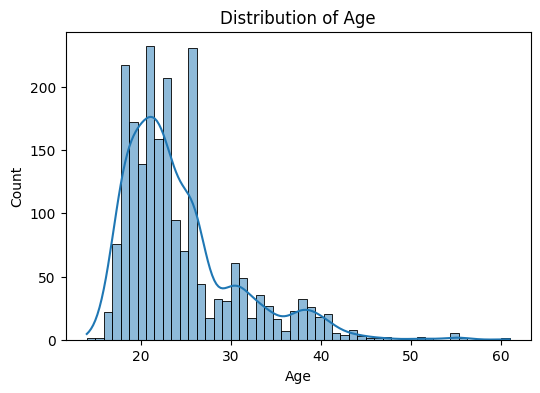

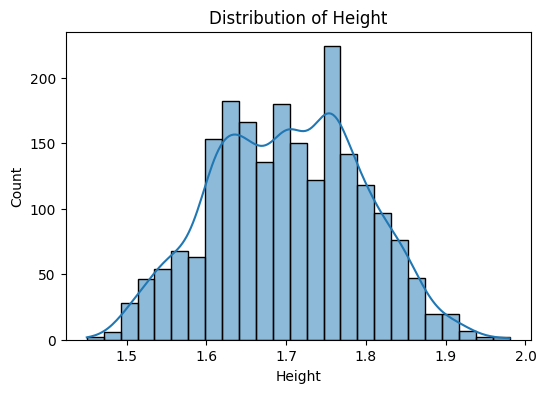

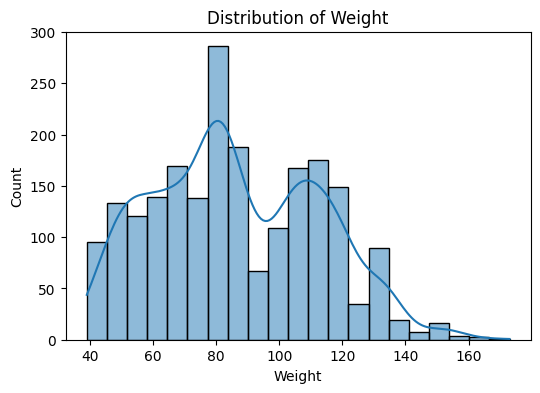

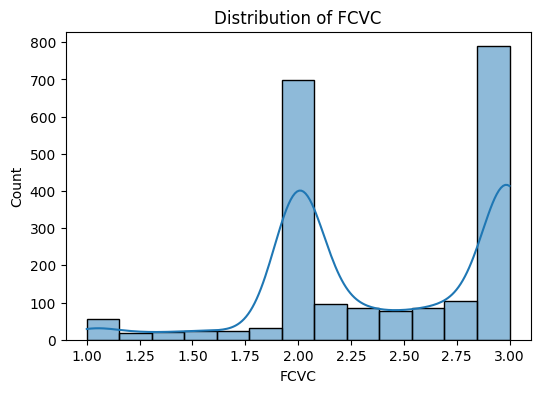

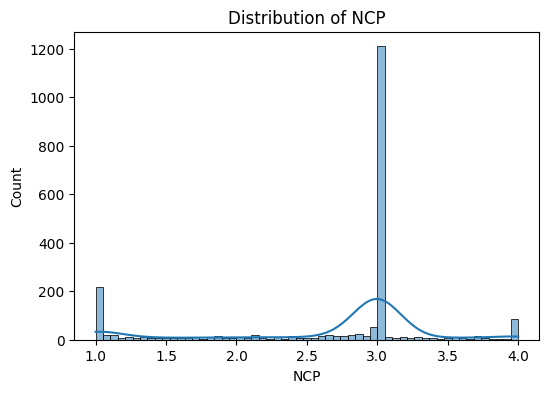

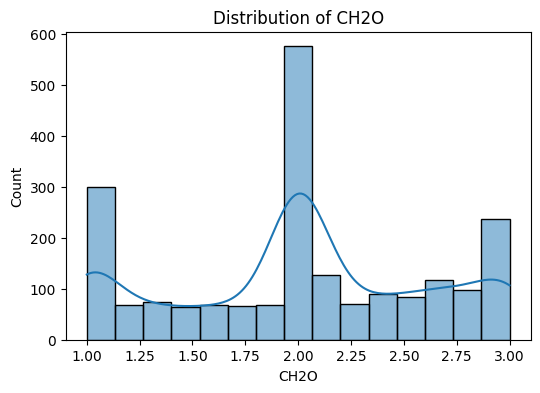

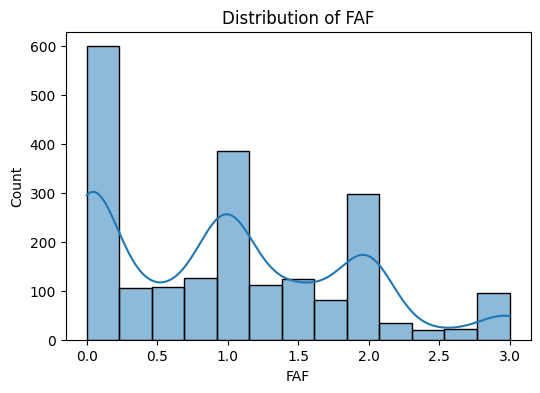

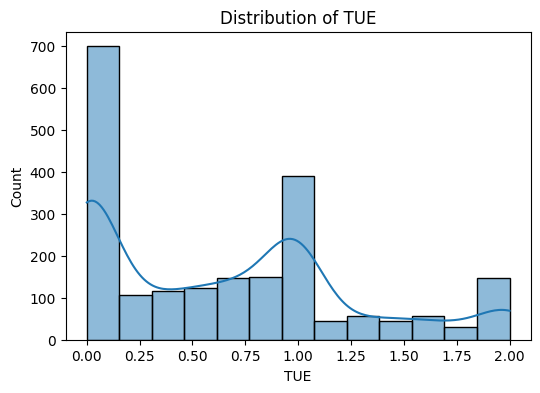

In [8]:

for col in df.select_dtypes(include='float64').columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


### Observations:
1. Age
Distribution: Right-skewed.
Observation:
Most individuals are aged between 18 and 25.
Sharp drop-off after 30 years.
A few outliers exist beyond 40–60.

Insight:
Data is skewed towards younger adults.
Obesity trends analyzed may reflect youth behavior more than older age groups.

2. Height
Distribution: Near normal (bell-shaped).
Observation:
Peak around 1.65m to 1.75m.
Range: 1.45m to ~2.0m.

Insight:
Population has standard height distribution.
Height likely won’t need transformation; useful for BMI calculation.

3. Weight
Distribution: Right-skewed with small tail.
Observation:
Majority weights between 60–120 kg.
Mode at 90–100 kg.
Some heavy outliers (150+ kg).

Insight:
Broad spread; includes underweight to morbid obesity.
Strong candidate feature for predicting obesity level.

4. FCVC (Vegetable Consumption Frequency)
Distribution: Bimodal.
Observation:
Peaks at 2 and 3, indicating high vegetable consumption.
Few users with low FCVC (1.0).

Insight:
Many individuals follow healthy vegetable habits.
Could serve as an inverse indicator of obesity (higher FCVC → less obesity).

5. NCP (Number of Meals Per Day)
Distribution: Strong peak at 3.
Observation:
Very sharp spike at NCP = 3, minimal elsewhere.
Few entries at 1, 2, or 4 meals.

Insight:
Most people follow the standard 3-meal pattern.
Could reflect eating habit norms; low variation may reduce predictive power unless linked with snack behavior (CAEC).

6. CH2O (Water Intake)
Distribution: Trimodal.
Observation:
Peaks at 1.0, 2.0, and 3.0 liters.
Largest at 2.0 liters.

Insight:
Suggests people fall into distinct hydration categories.
May help identify whether poor hydration correlates with obesity.

7. FAF (Physical Activity Frequency)
Distribution: Trimodal or multimodal.
Observation:
Many people report zero activity.
Peaks around 1 and 2 (moderate activity).

Insight:
Physical activity shows diversity in behavior.
Strong candidate to explain weight differences.

8. TUE (Time Using Technology/Screen Time)
Distribution: Bimodal/multimodal.
Observation:
Large spike at 0 hours, smaller at 1 and 2 hours.
Long tail between 0.25 and 1.75.

Insight:
Many users report no screen time (possibly due to misunderstanding or synthetic data).
Sedentary behavior could be inferred when correlated with obesity class.

### Boxplot Showing Spread and Outliers (univariate detection)

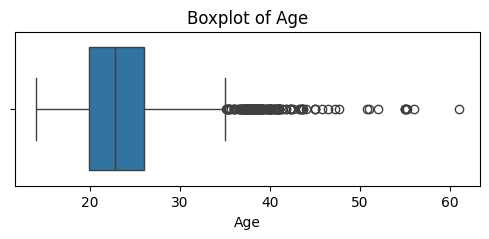

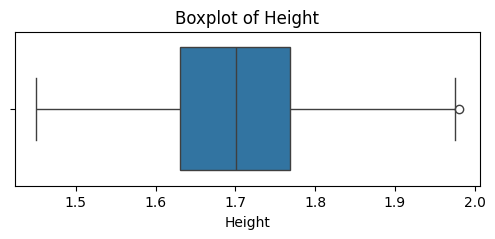

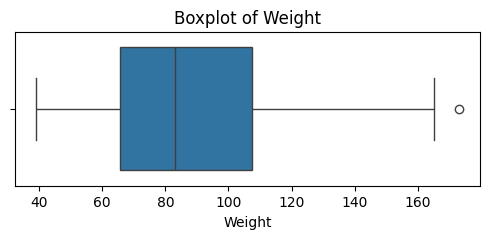

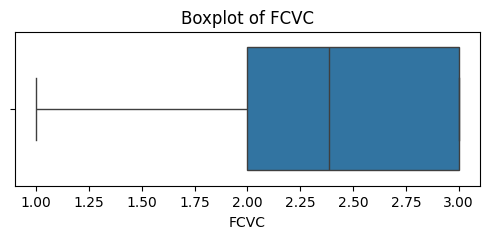

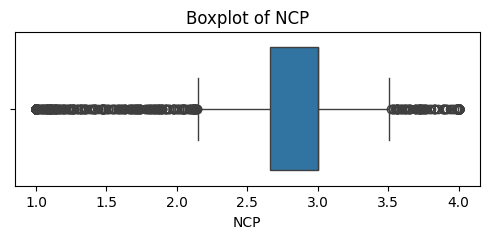

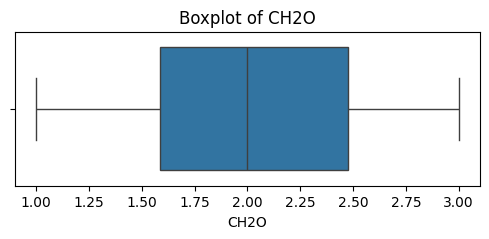

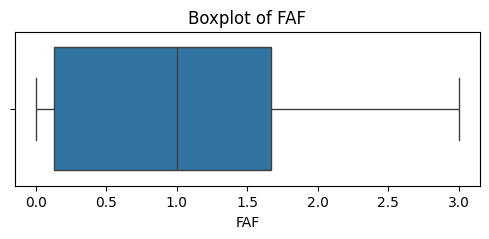

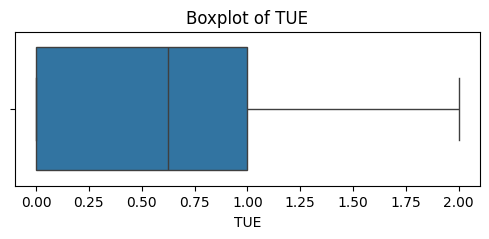

In [9]:
for col in df.select_dtypes(include='float64').columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


### Scatter Plot of Height and Weight Across Obesity Categories

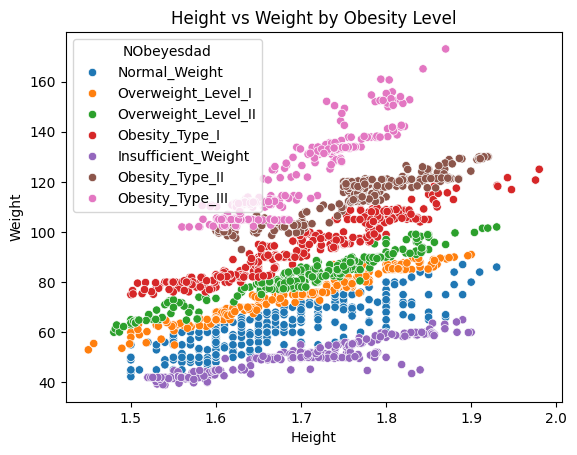

In [10]:
sns.scatterplot(data=df, x='Height', y='Weight', hue='NObeyesdad')
plt.title("Height vs Weight by Obesity Level")
plt.show()


### Observation:
Normal_Weight (blue):
Forms a linear band at moderate weights (55–75kg) and moderate heights (1.6–1.8m).
Closely clustered, suggesting consistent BMI values.
Represents a baseline "healthy" region in the plot.
Insight:
This group shows expected proportionality between height and weight.
Useful for identifying deviations that define overweight or obesity.

Insufficient_Weight (light purple):
Low weights (<60kg), seen across most heights (especially <1.7m).
Some data points fall below the normal weight line.
Insight:
Even tall individuals can be underweight.
Indicates nutritional deficiency or under-eating regardless of height.

Overweight_Level_I (orange):
Slightly above normal weight group.
Weights range from 65kg to 90kg across average heights.
Starts to diverge from the blue band upward.
Insight:
Marks the transition zone from normal to unhealthy weight gain.
Gradual increase in weight relative to height.

Overweight_Level_II (green):
Further above Level I.
Weight from 75kg to 100kg, across mid-height range.
Still mostly in the 1.6–1.8m height band.
Insight:
Indicates a second stage of weight gain.
Spread shows some overlap with Level I and Obesity Type I, suggesting blurred boundaries.

Obesity_Type_I (red):
Begins around 85kg and extends above 110kg.
Clearly separated from normal and overweight bands.
Denser near 1.65–1.75m heights.
Insight:
A marked escalation in weight for the same height range.
BMI likely crosses 30 here.

Obesity_Type_II (dark gray):
Denser cluster around 100–130kg.
Height does not change much—mainly 1.6–1.8m.
Insight:
Drastic weight gain over constant height implies steep BMI rise.
High health risk zone.

Obesity_Type_III (pink):
Most extreme weights (130kg to 165kg+).
Found in mid-height individuals.
Clearly topmost cluster on the plot, well-separated.
Insight:
Severe obesity, often categorized as morbid obesity.
Minimal overlap with other categories, making it easy to identify.
Candidates for high-risk interventions.

### Detection and Display of Duplicate Rows in the Dataset

In [6]:
# Count total duplicate rows (excluding the first occurrence)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Show actual duplicate rows (optional)
duplicates = df[df.duplicated()]
display(duplicates)


Number of duplicate rows: 24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
467,Male,22.0,1.74,75.0,yes,yes,3.0,3.0,Frequently,no,1.0,no,1.0,0.0,no,Automobile,Normal_Weight
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight


### Removing Duplicates

In [7]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   object 
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   object 
 5   FAVC                            2087 non-null   object 
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   object 
 9   SMOKE                           2087 non-null   object 
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   object 
 12  FAF                             2087 no

### Observation:
Duplicate rows are removed resulting  with 2087 entries.

### Outlier Detection Using DBSCAN

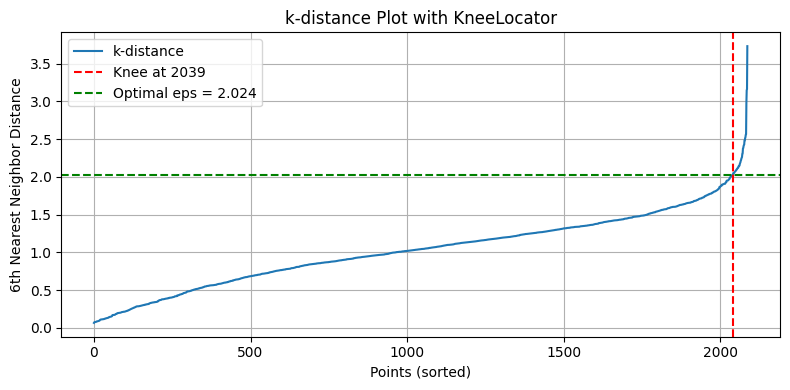

 Optimal eps from k-distance curve: 2.024


In [8]:
from kneed import KneeLocator

# Select numeric features
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
X = df[numeric_cols].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute k-distances
k = 6
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort distances of the k-th neighbor
k_distances = np.sort(distances[:, k-1])

# Use KneeLocator to find the elbow point (optimal eps)
kneedle = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
eps_val = k_distances[kneedle.knee]

# Plot k-distance graph with knee
plt.figure(figsize=(8, 4))
plt.plot(k_distances, label="k-distance")
plt.axvline(kneedle.knee, color='r', linestyle='--', label=f"Knee at {kneedle.knee}")
plt.axhline(eps_val, color='g', linestyle='--', label=f"Optimal eps = {eps_val:.3f}")
plt.title("k-distance Plot with KneeLocator")
plt.xlabel("Points (sorted)")
plt.ylabel(f"{k}th Nearest Neighbor Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output eps
print(f" Optimal eps from k-distance curve: {eps_val:.3f}")




### Observation:
Based on elbow method and knee locator, the value of eps is finalized to be 2.

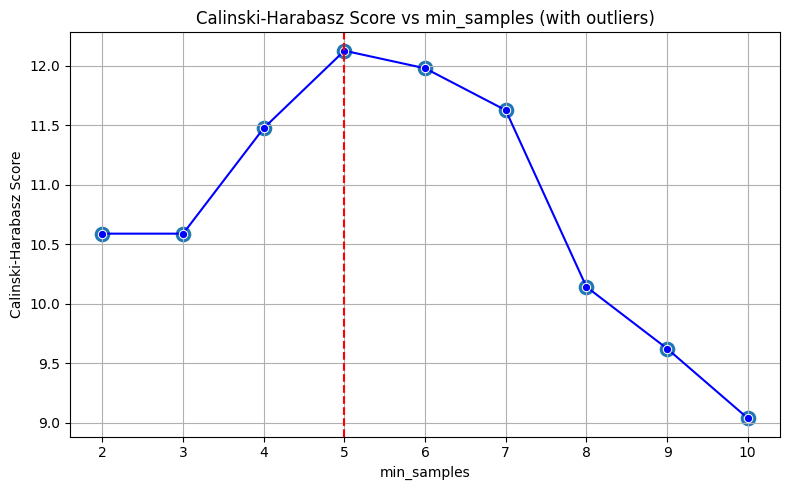


 Best min_samples (by Calinski-Harabasz) = 5
 Best Calinski-Harabasz score = 12.13

 Full evaluation table:

    Silhouette Score  Calinski-Harabasz  Davies-Bouldin
2              0.309             10.588           1.800
3              0.309             10.588           1.800
4              0.296             11.475           1.825
5              0.284             12.126           1.865
6              0.290             11.978           2.044
7              0.293             11.625           2.228
8              0.287             10.141           2.550
9              0.281              9.623           2.747
10             0.267              9.037           3.161

 Total outliers detected: 9


'\n Sample outliers:\n'

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,DBSCAN_Cluster_All
92,Male,55.0,1.78,84.0,yes,no,3.0,4.0,Frequently,no,3.0,yes,3.0,0.0,Frequently,Walking,Overweight_Level_I,-1
409,Female,33.0,1.55,55.0,yes,yes,3.0,1.0,Sometimes,no,3.0,no,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,-1
358,Male,41.0,1.75,110.0,yes,no,2.0,1.0,Sometimes,no,1.0,no,1.0,0.0,Frequently,Automobile,Obesity_Type_II,-1
232,Female,51.0,1.59,50.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,2.0,0.0,no,Public_Transportation,Normal_Weight,-1
396,Female,38.0,1.55,59.0,yes,no,3.0,3.0,Sometimes,no,1.0,no,2.0,1.0,Frequently,Automobile,Normal_Weight,-1


In [9]:

# Step 1: Select and scale numeric features
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
X = df[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: DBSCAN parameter settings
eps_val = 2  # Choose based on knee/elbow method
min_samples_range = range(2, 11)

# Step 3: Evaluate DBSCAN using all 3 metrics
silhouette_scores = {}
calinski_scores = {}
davies_scores = {}

for m in min_samples_range:
    dbscan = DBSCAN(eps=eps_val, min_samples=m).fit(X_scaled)
    labels = dbscan.labels_
    
    if len(set(labels)) > 1:
        try:
            silhouette = silhouette_score(X_scaled, labels)
            calinski = calinski_harabasz_score(X_scaled, labels)
            davies = davies_bouldin_score(X_scaled, labels)
        except:
            silhouette, calinski, davies = np.nan, np.nan, np.nan
    else:
        silhouette, calinski, davies = np.nan, np.nan, np.nan

    silhouette_scores[m] = silhouette
    calinski_scores[m] = calinski
    davies_scores[m] = davies

# Step 4: Create DataFrame for evaluation
scores_df = pd.DataFrame({
    "Silhouette Score": pd.Series(silhouette_scores),
    "Calinski-Harabasz": pd.Series(calinski_scores),
    "Davies-Bouldin": pd.Series(davies_scores)
})

# Step 5: Plot Calinski-Harabasz Scores
plt.figure(figsize=(8, 5))
sns.lineplot(data=scores_df["Calinski-Harabasz"], marker='o', color='blue')
sns.scatterplot(x=scores_df.index, y=scores_df["Calinski-Harabasz"], s=150)
plt.axvline(x=scores_df["Calinski-Harabasz"].idxmax(), color='red', linestyle='--')
plt.title("Calinski-Harabasz Score vs min_samples (with outliers)")
plt.xlabel("min_samples")
plt.ylabel("Calinski-Harabasz Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6: Select best min_samples based on Calinski
best_min_samples = scores_df["Calinski-Harabasz"].idxmax()
best_score = scores_df.loc[best_min_samples, "Calinski-Harabasz"]

print(f"\n Best min_samples (by Calinski-Harabasz) = {best_min_samples}")
print(f" Best Calinski-Harabasz score = {best_score:.2f}")
print("\n Full evaluation table:\n")
print(scores_df.round(3))

# Step 7: Final DBSCAN run with best parameters
dbscan = DBSCAN(eps=eps_val, min_samples=best_min_samples).fit(X_scaled)
labels = dbscan.labels_
df['DBSCAN_Cluster_All'] = labels

# Step 8: Outlier reporting
outliers = df[df['DBSCAN_Cluster_All'] == -1]
print(f"\n Total outliers detected: {len(outliers)}")
display("\n Sample outliers:\n", outliers.sample(min(5, len(outliers))))


### Observation:
Based on the best Calinski-Harabasz value min_sample was selected to be 5 and the outlier detected is 9.

In [10]:
# Step 9: Remove outliers (label = -1)
df_cleaned = df[df['DBSCAN_Cluster_All'] != -1].copy()

# Step 10: Drop extra outlier label columns if they exist
columns_to_drop = ['DBSCAN_Cluster_All', 'Outlier_Silhouette', 'Outlier_Calinski']
df_cleaned.drop(columns=[col for col in columns_to_drop if col in df_cleaned.columns], inplace=True)

# Step 11: Summary
print(f" Final dataset shape after removing DBSCAN outliers: {df_cleaned.shape}")
print(f" Total outliers removed: {df.shape[0] - df_cleaned.shape[0]}")




 Final dataset shape after removing DBSCAN outliers: (2078, 17)
 Total outliers removed: 9


### Observation:
DBSCAN was used for outlier removal with total outlier removed being 9.

### Outlier Detection Using Isolation Forest

In [11]:
from sklearn.ensemble import IsolationForest

# Use scaled data
X = df[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_labels = iso_forest.fit_predict(X_scaled)

# Label outliers (-1) and inliers (1)
df['Outlier_IsolationForest'] = iso_labels
outliers_iso = df[df['Outlier_IsolationForest'] == -1]

# Summary
print(f" Total outliers detected by Isolation Forest: {len(outliers_iso)}")
print("\n Sample outliers:")
display(outliers_iso.sample(min(5, len(outliers_iso))))


 Total outliers detected by Isolation Forest: 21

 Sample outliers:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,DBSCAN_Cluster_All,Outlier_IsolationForest
188,Male,35.000000,1.780000,105.000000,yes,yes,3.00000,1.000000,no,no,3.000000,no,3.000000,1.0,Frequently,Automobile,Obesity_Type_I,0,-1
30,Male,29.000000,1.770000,83.000000,no,yes,1.00000,4.000000,Frequently,no,3.000000,no,0.000000,1.0,no,Motorbike,Overweight_Level_I,0,-1
92,Male,55.000000,1.780000,84.000000,yes,no,3.00000,4.000000,Frequently,no,3.000000,yes,3.000000,0.0,Frequently,Walking,Overweight_Level_I,-1,-1
1,Female,21.000000,1.520000,56.000000,yes,no,3.00000,3.000000,Sometimes,yes,3.000000,yes,3.000000,0.0,Sometimes,Public_Transportation,Normal_Weight,0,-1
1212,Male,39.759575,1.792507,101.780099,yes,yes,2.33361,2.113575,Sometimes,no,2.504136,no,2.998981,1.0,Sometimes,Automobile,Obesity_Type_I,0,-1


### Observation:
Another Multivariate Outlier detection Algorithm - Isolation forest detected 21 outliers.

### Comparison of Outliers Detected by DBSCAN and Isolation Forest

In [12]:
# Indexes of outliers
dbscan_outlier_idx = set(outliers.index)
iso_outlier_idx = set(outliers_iso.index)

# Common outliers
common_idx = dbscan_outlier_idx & iso_outlier_idx

# Unique to DBSCAN
only_dbscan_idx = dbscan_outlier_idx - iso_outlier_idx

# Unique to Isolation Forest
only_iso_idx = iso_outlier_idx - dbscan_outlier_idx

# Print summary
print(f" Common outliers: {len(common_idx)}")
print(f" Only DBSCAN outliers: {len(only_dbscan_idx)}")
print(f" Only Isolation Forest outliers: {len(only_iso_idx)}")


 Common outliers: 1
 Only DBSCAN outliers: 8
 Only Isolation Forest outliers: 20


### Observation:
Upon comparison only 1 outlier was common in Isolation forest and DBSCAN.

### Descriptive Statistics Summary of Cleaned Obesity Dataset

In [18]:
# Numeric summary
df_cleaned.describe(include='all').transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2078,2,Male,1049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2078.0,NaN,NaN,NaN,24.270403,6.207719,14.0,19.88821,22.830929,26.0,56.0
Height,2078.0,NaN,NaN,NaN,1.702873,0.093155,1.45,1.630467,1.701642,1.769495,1.98
Weight,2078.0,NaN,NaN,NaN,86.925009,26.201715,39.0,66.0,83.136481,108.038038,173.0
family_history_with_overweight,2078,2,yes,1715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2078,2,yes,1839,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,2078.0,NaN,NaN,NaN,2.420885,0.533921,1.0,2.0,2.393251,3.0,3.0
NCP,2078.0,NaN,NaN,NaN,2.703254,0.761976,1.0,2.701563,3.0,3.0,4.0
CAEC,2078,4,Sometimes,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2078,2,no,2036,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observation:
#### Numerical Features:
Age:
Mostly young adults.
Range: 14 to 56 years.

Height & Weight:
Avg height = 1.70 m; avg weight = 86.9 kg -> indicates overweight/obese population.
Weight range is wide (39 to 173 kg), suggesting high variance.

FCVC (Vegetable consumption):
Median = 2.4 (on a 1–3 scale), showing moderate intake.

NCP (Meals per day):
Most have 3 meals/day; low variability.

CH2O (Water intake):
Median = 2 liters/day, which is adequate.

FAF (Physical activity):
Low average (1.0 hrs/week), suggesting sedentary lifestyle.

TUE (Technology use):
Median = 0.63 hrs/day, indicating moderate screen time.

#### Categorical Features:
Gender: Balanced (Male: 1049, Female: 1029).
Family history of overweight: High prevalence (82% say "yes").
FAVC (Frequent high-calorie food): 88% consume frequently.
CAEC (Snacking): Majority (84%) snack "Sometimes".
SMOKE: Very few smokers (only 2%).
SCC (Calories monitoring): Only 5% monitor calories.
CALC (Alcohol use): 66% "Sometimes", only 1 "Always".
MTRANS (Transport): 75% use public transportation.

### Bivariate EDA (Exploratory Data Analysis)

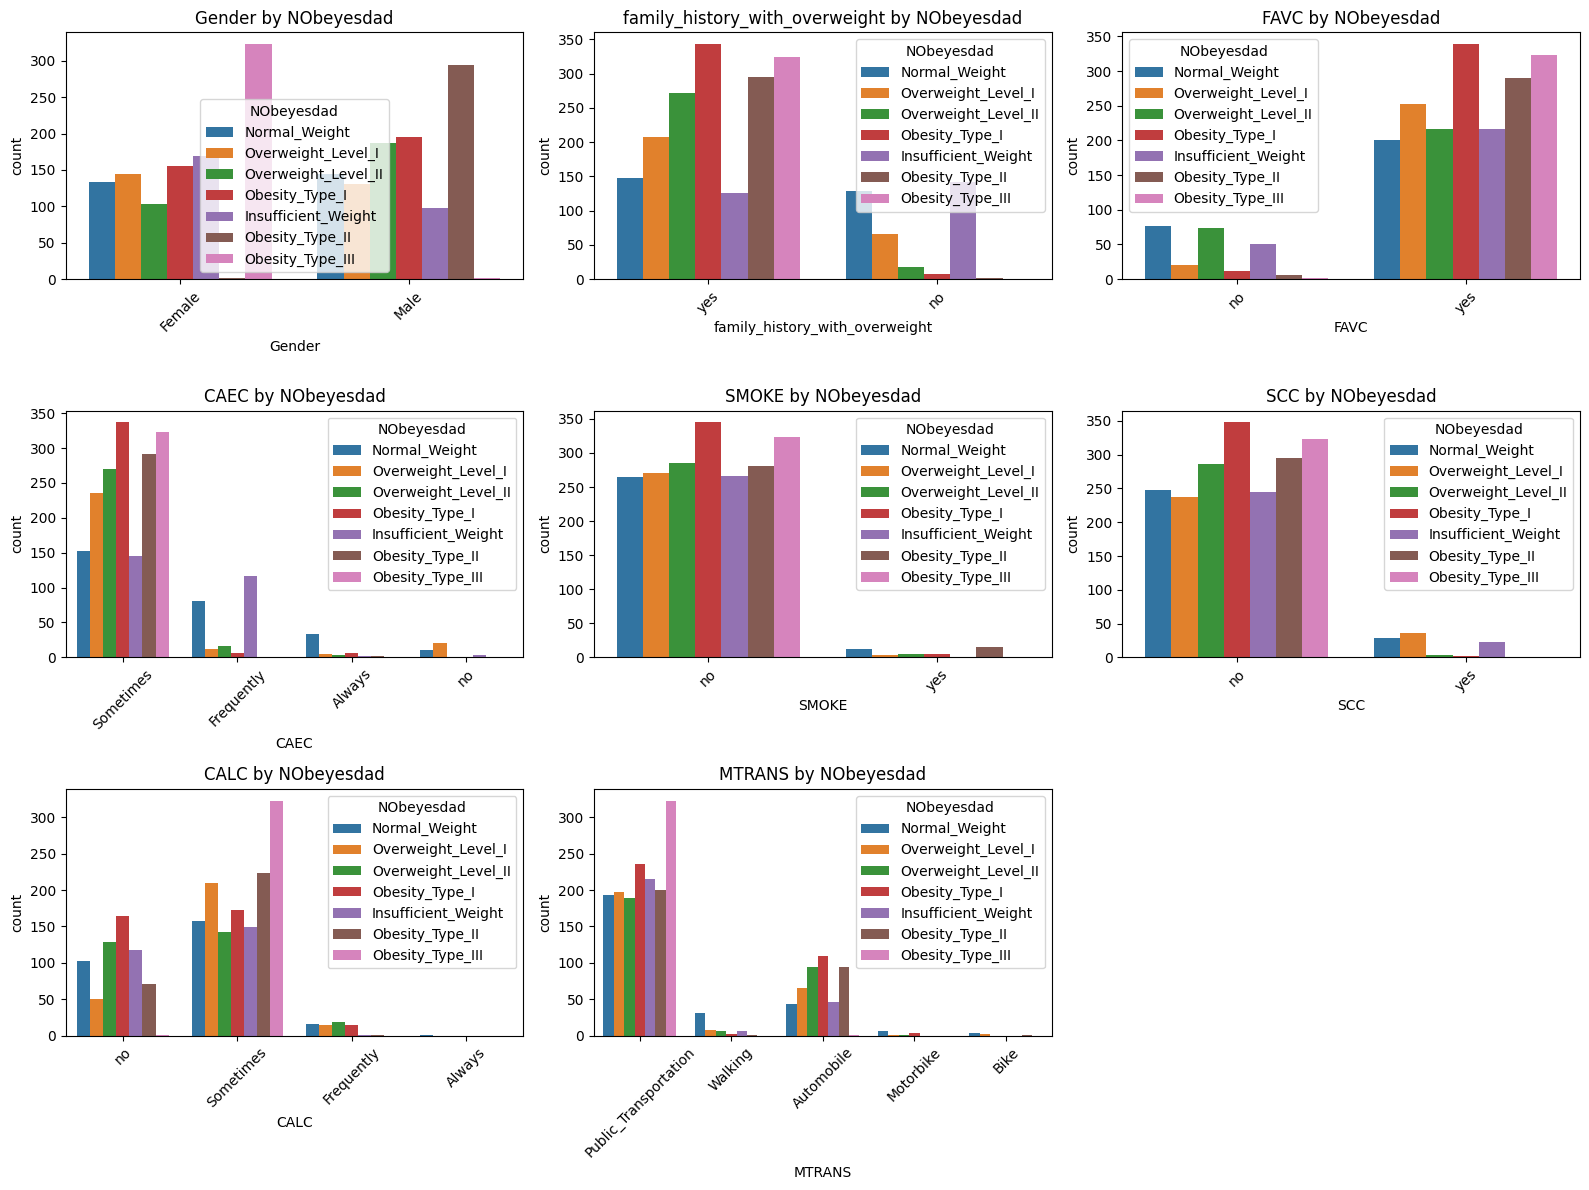

In [19]:
# Define categorical columns
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC',
                    'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

# Plot countplots for all categorical variables against NObeyesdad
plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols[:-1], 1):  # Exclude target itself
    plt.subplot(3, 3, i)
    sns.countplot(data=df_cleaned, x=col, hue='NObeyesdad')
    plt.xticks(rotation=45)
    plt.title(f'{col} by NObeyesdad')
plt.tight_layout()
plt.show()


### Categorical Variables vs. NObeyesdad (Countplots)

#### Major insights-

1.Gender: Males are slightly overrepresented in extreme obesity categories.

2.Family History (family_history_with_overweight): Strong positive correlation with obesity levels.

3.High-Calorie Food Consumption (FAVC): Strongly associated with all obesity classes — majority of obese individuals responded "Yes".

4.Snacking Between Meals (CAEC): Frequently and sometimes snacking is more prevalent in obese individuals.

5.Smoking: No strong trend; most individuals are non-smokers across classes.

6.Calories Monitoring (SCC): People who monitor calories are more likely to be Normal_Weight.

7.Alcohol Consumption (CALC): Mixed trend; some obese groups report "No", possibly due to lifestyle or comorbidities.

8.Transport Mode (MTRANS): Obese individuals use less physically active transport (e.g., public transport or car), while walkers are more common in Normal_Weight.


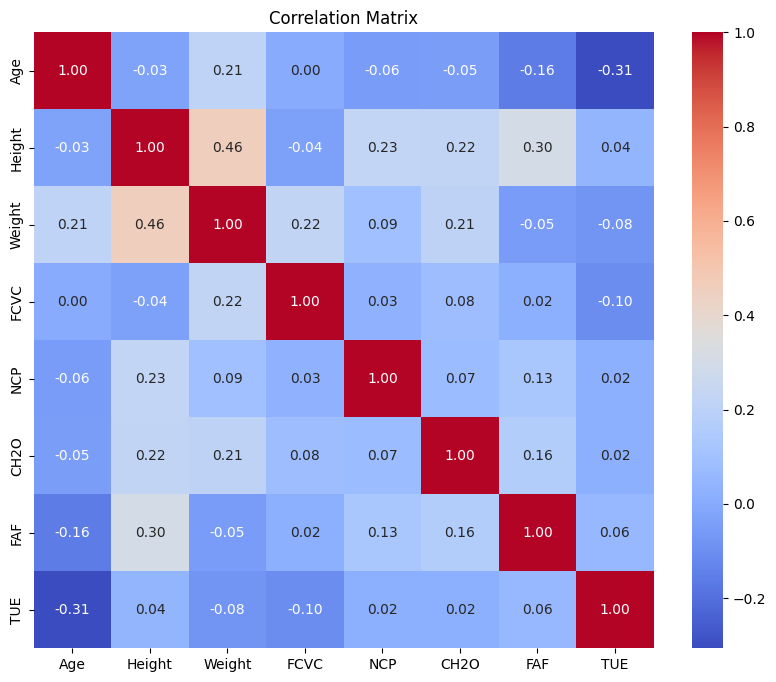

In [20]:
numerical_cols = df_cleaned.select_dtypes(include=['float64']).columns
corr = df_cleaned[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


### Significance:
This correlation matrix is a useful first step in assessing multicollinearity for models sensitive to correlated predictors, such as Logistic Regression and Linear Discriminant Analysis (LDA).
Since none of the pairwise correlation coefficients exceed 0.9, there is no immediate indication of severe multicollinearity. Therefore, the data passes the basic multicollinearity check based on correlation.

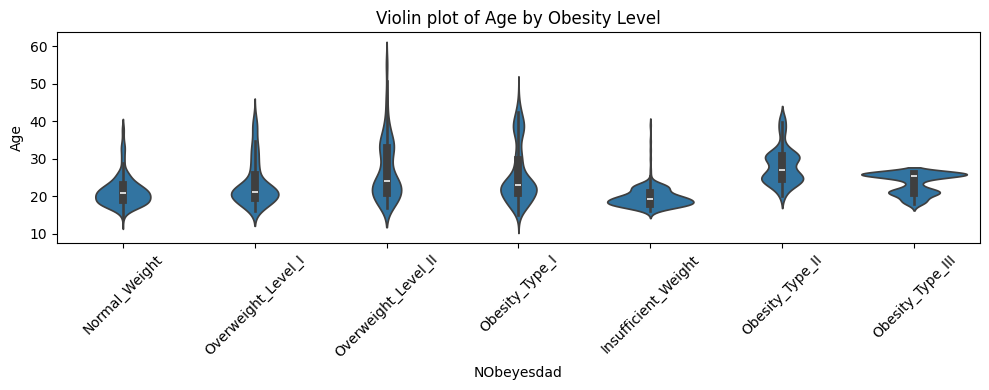

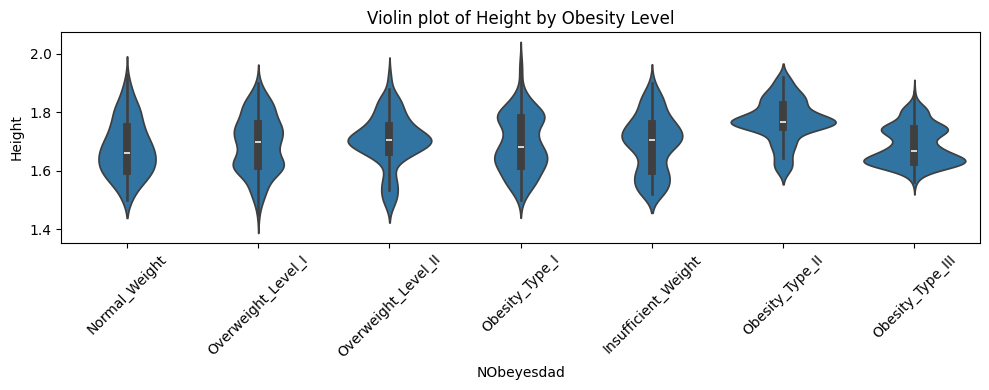

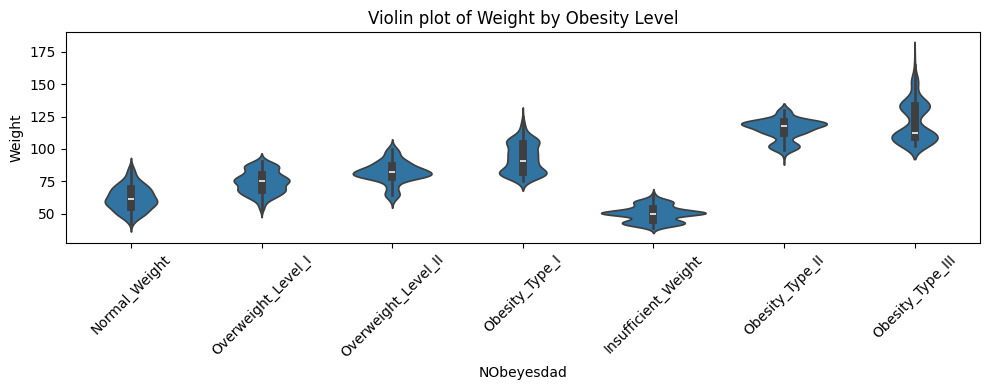

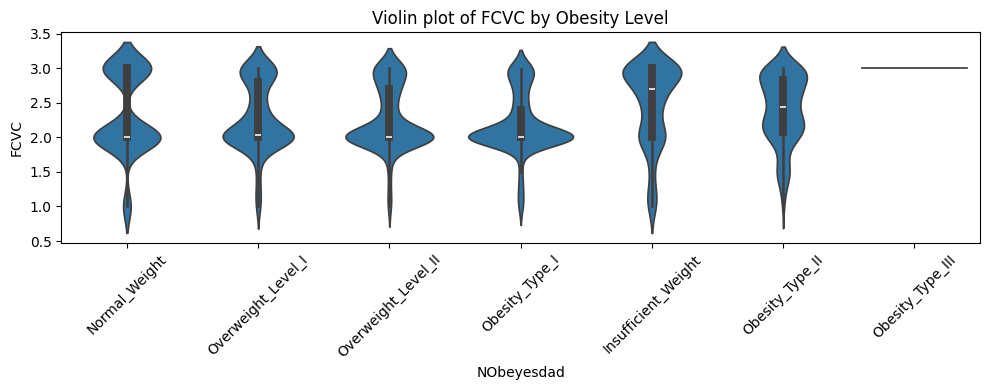

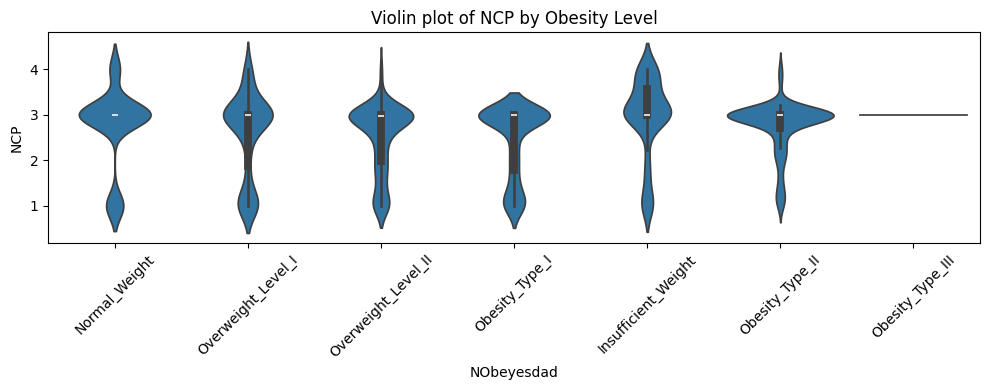

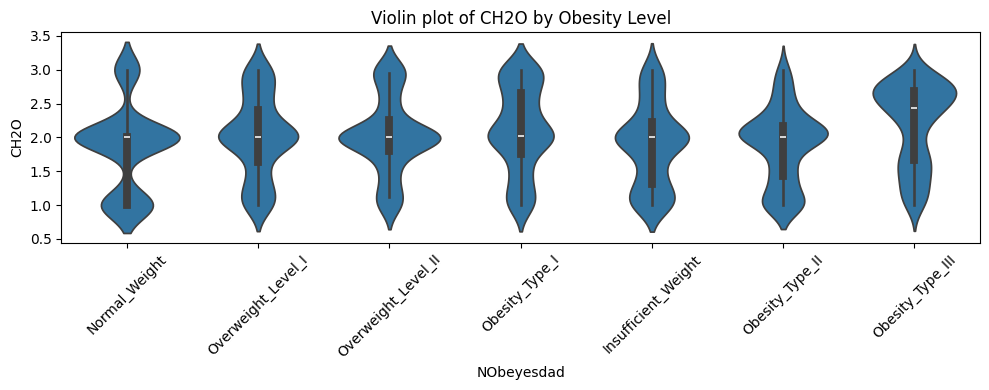

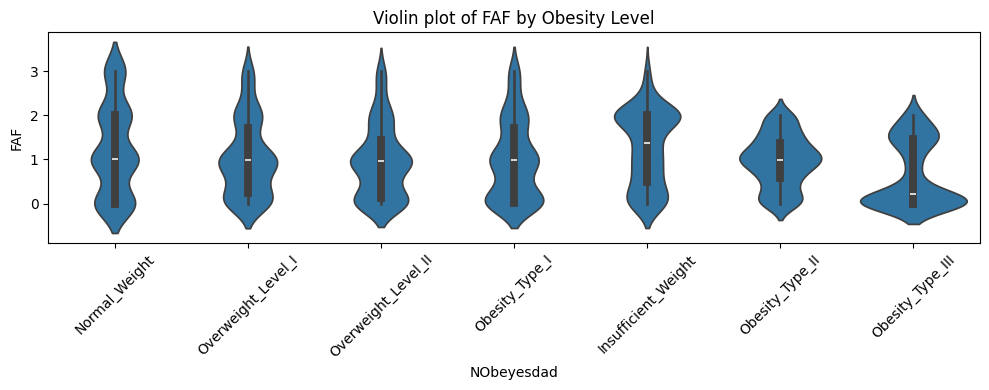

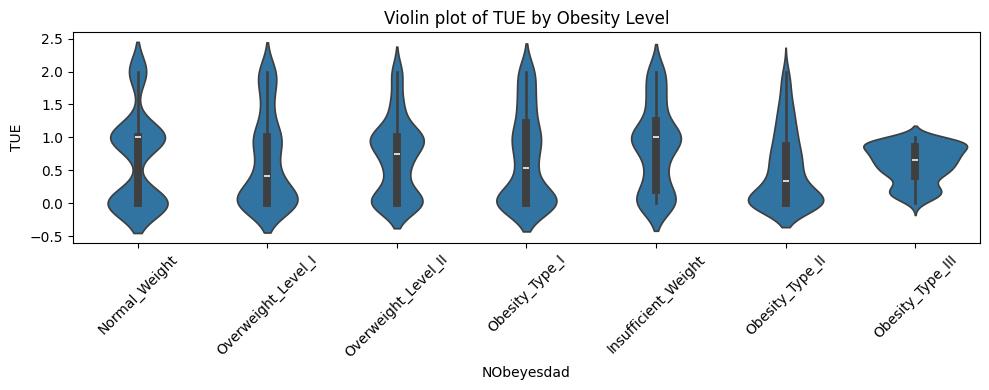

In [21]:
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.violinplot(data=df_cleaned, x='NObeyesdad', y=col)
    plt.title(f'Violin plot of {col} by Obesity Level')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Key Observations & Insights from the Violin Plots

1. Age by Obesity Level
Normal Weight to Obesity Type I: Broad age distribution, centered around the mid-20s.
Insufficient Weight: Skewed toward younger individuals (mainly early 20s).
Obesity Type II & III: Tightly clustered around younger age (less variance), with lower mean than expected.

Insight:
Most obese individuals in this dataset are young adults, indicating early onset obesity, possibly due to lifestyle habits. Insufficient weight is also more common in younger age groups, suggesting issues like undernutrition in youth.


2. Height by Obesity Level
Most distributions center between 1.6 to 1.75 meters.
Insufficient Weight individuals tend to be shorter.
Obesity Type III includes slightly shorter individuals too.

Insight:
While height doesn’t vary dramatically, extreme obesity and underweight groups show slight association with shorter stature—possibly a secondary indicator tied to childhood nutritional or genetic factors.


3. Weight by Obesity Level
Strong positive trend:
Weight increases sharply from Normal -> Overweight -> Obese.
Obesity_Type_III shows the widest and highest distribution (some >150 kg).
Insufficient_Weight is tightly concentrated at the low end (40–60 kg).

Insight:
As expected, weight is a highly discriminative feature for obesity classification. It alone could serve as a key predictive variable in a supervised model.


4. FCVC (Frequency of Vegetable Consumption)
Median values are similar (2.5) across all categories.
Obesity_Type_III shows no variation—possibly a data issue or imbalanced class.
Distributions are slightly more left-skewed in higher obesity types (i.e., fewer vegetables).

Insight:
Lower vegetable consumption is slightly more common in obesity levels, which supports dietary impact on weight. The flat distribution for Type III suggests potential missing or constant data.


5. NCP (Number of Meals per Day)
Central tendency hovers around 3 meals for all categories.
Slightly higher variance in obese and insufficient groups.
Obesity_Type_III appears more uniform and flat—again, could indicate fixed or poor-quality data for this group.

Insight:
Most individuals, regardless of weight, consume 3 meals/day, but meal quantity alone isn't sufficient—meal content and snacking behavior may matter more (explored in CAEC or FAVC).



6. CH2O (Water Intake)
Median around 2 liters/day across all groups.
Obesity_Type_II and III show slightly higher medians and range.
Distribution shapes are similar—bell-shaped and consistent.

Insight:
Water consumption doesn’t differ significantly across weight categories. Any correlation here is weak and not highly informative for classification.


7. FAF (Physical Activity)
Higher physical activity (2–3) in Normal_Weight and Overweight_Level_I.
Obesity_Type_III has a clear drop in physical activity (concentrated near 0).
Insufficient_Weight shows higher activity—could be due to hyperactivity, stress, or other lifestyle factors.

Insight:
Lower physical activity strongly correlates with higher obesity levels. This is a crucial behavioral feature and should be weighted significantly in predictive models or interventions.



8. TUE (Technology Use)
Obesity_Type_II and III: More technology usage (1.2+ hours/day).
Normal_Weight group has a lower median (0.5–1 hours/day).
Long tails in overweight groups show diversity in usage.
    
Insight:
Sedentary behavior via technology usage (screen time) increases with obesity. It can be a key risk factor and an actionable metric in lifestyle counseling.

### Multivariate EDA (Exploratory Data Analysis)

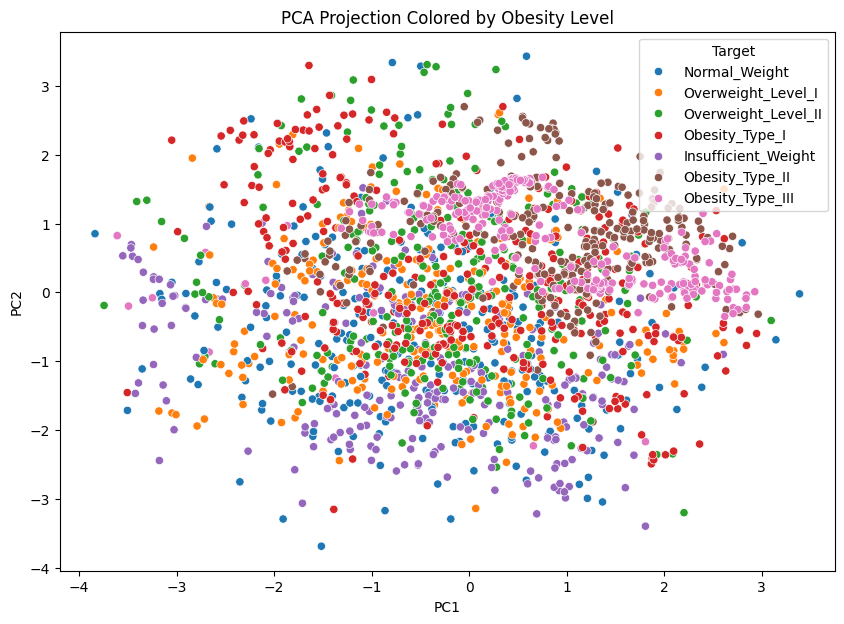

In [22]:

X = df_cleaned[numerical_cols]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_pca['Target'] = df['NObeyesdad']

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Target', palette='tab10')
plt.title("PCA Projection Colored by Obesity Level")
plt.show()


### PCA Projection Observation:

General Appearance: The clusters are highly overlapped, especially for Normal, Overweight, and Obesity Type I.
Obesity Type II and III show some mild separation, mostly toward the right side of the plot.
Interpretation Difficulty: Since PCA is linear, it struggles with complex, non-linear relationships in high-dimensional data (like human lifestyle + obesity).


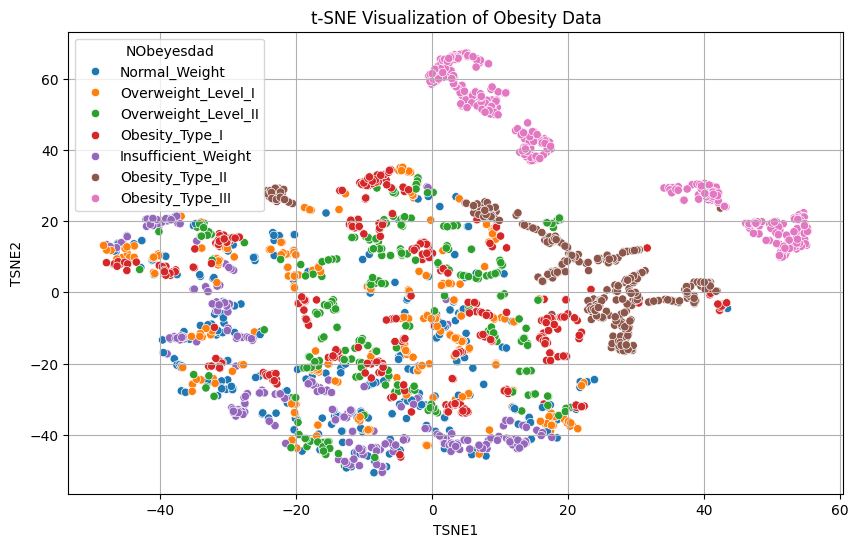

In [23]:

X = df_cleaned[numerical_cols]
y = df_cleaned['NObeyesdad']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plotting
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['NObeyesdad'] = y.values

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='NObeyesdad', palette='tab10')
plt.title("t-SNE Visualization of Obesity Data")
plt.grid(True)
plt.show()


### t-SNE Projection Observation:

Clear Clustering: Distinct clusters for Obesity Type II and Obesity Type III — much more visible than PCA.

Better Separation: Overweight I, II, and Normal Weight are somewhat overlapping but show some structure.

Complex Boundaries Captured: t-SNE clearly reveals that the obesity classes do not linearly separate in feature space.

### Valuable Insights:
t-SNE, being a non-linear embedding method, captured the local neighborhood structure much better. It visually uncovered well-separated clusters for Obesity Type II and III, indicating the potential for classification.

The overlap in t-SNE among Normal, Overweight I/II, and Obesity Type I suggests either:
a) feature overlap among these classes, or
b) labeling noise or fine-grained transition in real-world health data.

This visualization justifies the use of non-linear classifiers (e.g., Random Forest, XGBoost, SVM) for this problem instead of pure logistic regression or linear models.

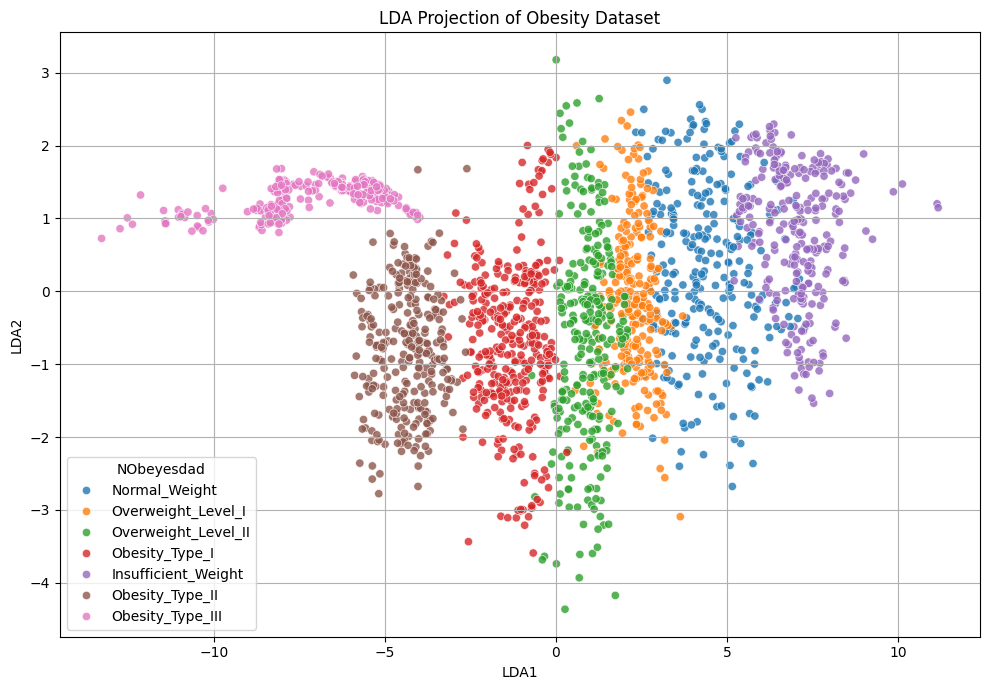

In [24]:

# Step 1: Select numeric features and target
X = df_cleaned[numerical_cols].copy()
y = df_cleaned['NObeyesdad'].copy()

# Step 2: Encode the target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 3: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Apply LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y_encoded)

# Step 5: Create a DataFrame for plotting
lda_df = pd.DataFrame(X_lda, columns=['LDA1', 'LDA2'])
lda_df['NObeyesdad'] = y.values

# Step 6: Visualize
plt.figure(figsize=(10, 7))
sns.scatterplot(data=lda_df, x='LDA1', y='LDA2', hue='NObeyesdad', palette='tab10', alpha=0.8)
plt.title('LDA Projection of Obesity Dataset')
plt.grid(True)
plt.tight_layout()
plt.show()


### Observations and Insights
#### 1. Class Separation
The LDA projection shows good class separation for most categories:
"Insufficient_Weight" (brown) and "Obesity_Type_III" (pink) are very distinct and clearly separated.
"Obesity_Type_II" (purple), "Obesity_Type_I" (red), and "Overweight_Level_II" (green) show some overlap, but are still distinguishable.
"Normal_Weight" (blue) and "Overweight_Level_I" (orange) are more centrally clustered and slightly overlapping.

#### 2. Class Clustering
The LDA components seem to organize the data in a roughly linear progression from underweight to extreme obesity along the LDA1 axis.
This suggests that LDA is effectively capturing the progressive nature of obesity in the dataset.

#### 3. Feature Relevance
Since LDA is supervised (it considers class labels), the directions (LDA1, LDA2) are combinations of features that maximize between-class variance and minimize within-class variance.
Hence, this plot indicates that the numerical features selected are informative in distinguishing obesity categories.

#### 4. Dimensionality Reduction Success
Despite reducing potentially many features to just 2, the separation is mostly preserved.
This confirms that LDA is a useful visualization and classification tool in this case.

### Normalized Distribution of NObeyesdad Classes per Agglomerative Cluster

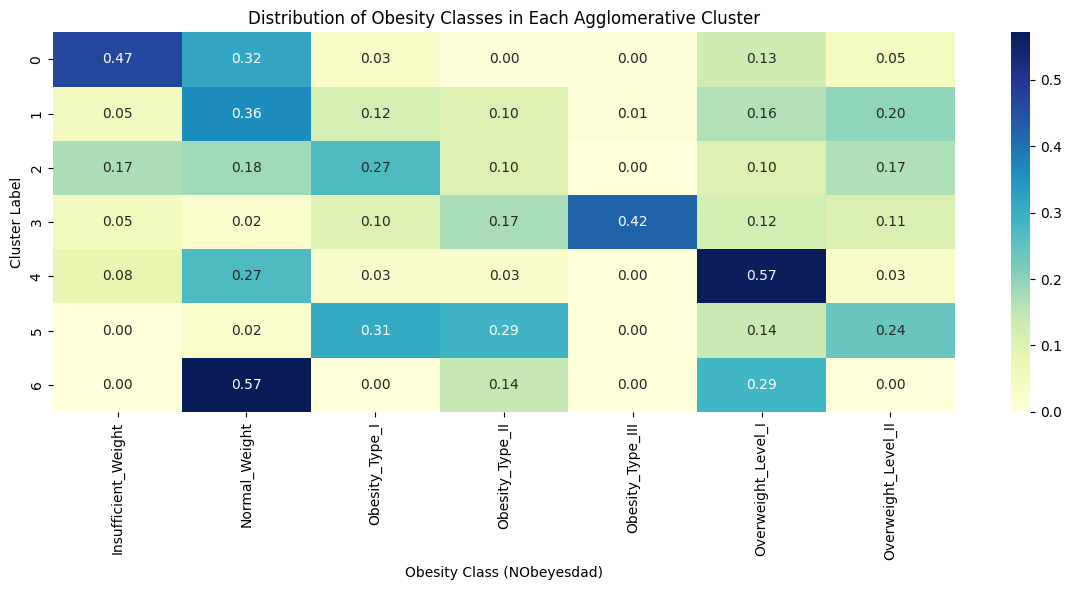

In [35]:

from sklearn.cluster import AgglomerativeClustering

# Step 1: Separate features and target
X = df_cleaned.drop(columns='NObeyesdad')
y = df_cleaned['NObeyesdad']

# Step 2: One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 3: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Step 4: Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=7)  # Set to 7 based on NObeyesdad classes
cluster_labels = agglo.fit_predict(X_scaled)

# Step 5: Add cluster labels to the cleaned DataFrame
df_cleaned['Cluster_Label'] = cluster_labels
df_cleaned['NObeyesdad'] = y.values  # Re-attach target to make sure it's available

# Step 6: Analyze cluster vs class label distribution
distribution = pd.crosstab(df_cleaned['Cluster_Label'], df_cleaned['NObeyesdad'], normalize='index')

# Step 7: Visualize as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(distribution, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Distribution of Obesity Classes in Each Agglomerative Cluster")
plt.xlabel("Obesity Class (NObeyesdad)")
plt.ylabel("Cluster Label")
plt.tight_layout()
plt.show()


### Cluster-Wise Insights:
#### Cluster 0: (Blue)
Dominant Class: Insufficient_Weight (47%)
Second Highest: Normal_Weight (32%)
Insight: This cluster mostly contains underweight and normal individuals. Possibly represents individuals with high physical activity or low calorie intake.

#### Cluster 1: (Orange)
Dominant Class: Normal_Weight (36%)
Secondary Classes: Overweight_Level_II (20%), Overweight_Level_I (16%)
Insight: This is a transitional cluster between normal weight and overweight categories.

#### Cluster 2: (Green)
Dominant Class: Obesity_Type_II (42%)
Secondary: Obesity_Type_I (27%)
Insight: This cluster represents people with more advanced obesity. Likely have lifestyle habits or conditions leading to more severe weight issues.

#### Cluster 3: (Red)
Dominant Class: Overweight_Level_I (57%)
Insight: Highly focused group. Cluster is dense and consistent with early-stage overweight individuals.

#### Cluster 4: (Purple)
Mixed Class: Highest is Normal_Weight (27%), others are scattered.
Insight: Likely a less coherent cluster, may be absorbing borderline or noisy data points.

#### Cluster 5: (Brown)
Dominant Class: Obesity_Type_I (31%)
Secondary: Overweight_Level_I (29%)
Insight: Transitional cluster between overweight and obese individuals. Could benefit from targeted health interventions.

#### Cluster 6: (Pink)
Dominant Class: Normal_Weight (57%)
Secondary: Overweight_Level_I (29%)
Insight: Mostly healthy weight individuals with some drifting toward overweight.

### Agglomerative Clustering Results (2D PCA Projection)

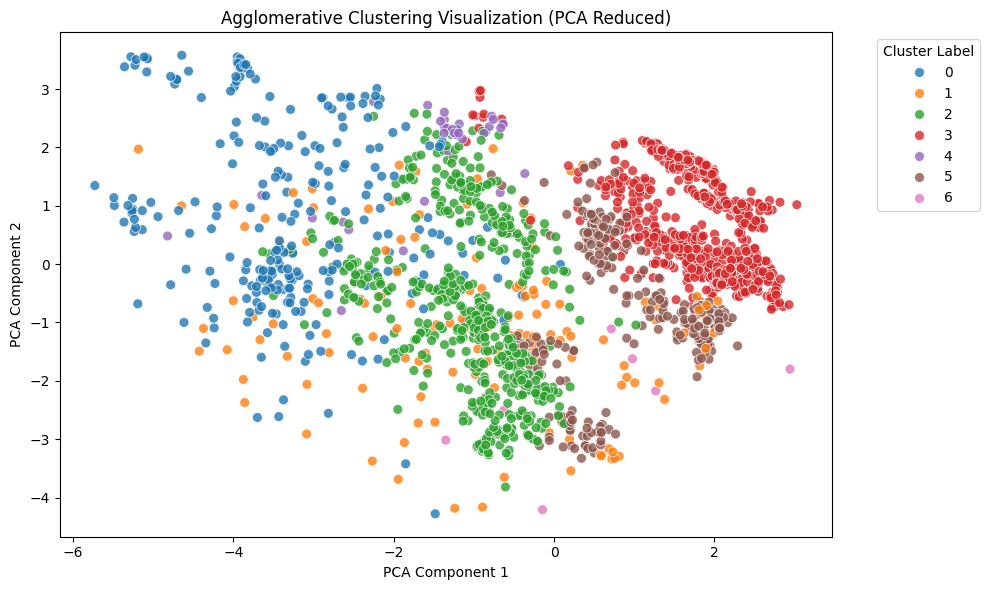

In [36]:

# Step 8: Reduce to 2D with PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 9: Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_cleaned['Cluster_Label'],
    palette='tab10', s=50, alpha=0.8
)
plt.title('Agglomerative Clustering Visualization (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


 ### Observations:
#### Well-Separated Clusters:
The red cluster (Cluster 3) and green cluster (Cluster 2) are highly compact and clearly separated in PCA space. This suggests distinct feature patterns in those groups.
Cluster 0 (blue) appears more dispersed, potentially indicating heterogeneity within that group.

#### Moderate Overlaps:
Overlaps are noticeable between clusters 0, 1, 4, and 6. These overlaps could hint at some borderline cases where data points share features across obesity levels.

#### Densely Populated Regions:
Central regions are more densely populated, especially where green (2), purple (5), and orange (1) points converge. These may represent intermediate obesity types (e.g., overweight or early obesity stages).

### Multiclass Classification Using LDA-Reduced Features with Multiple Machine Learning Models

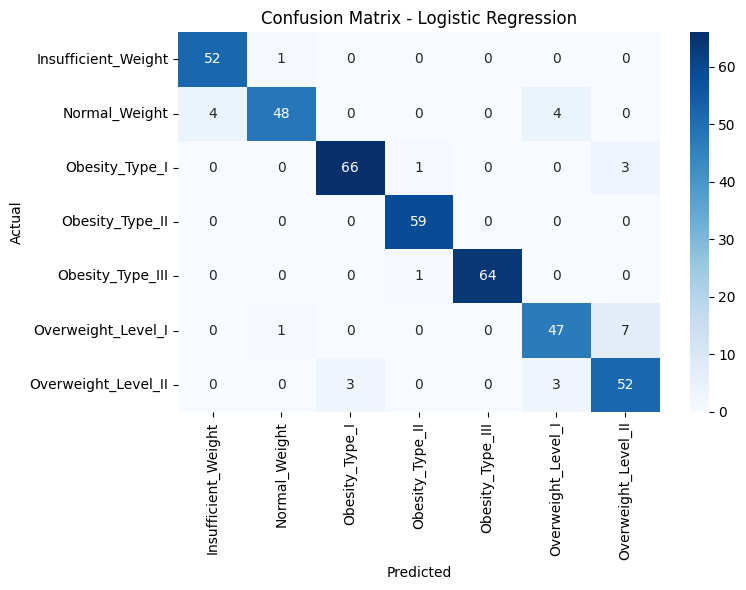

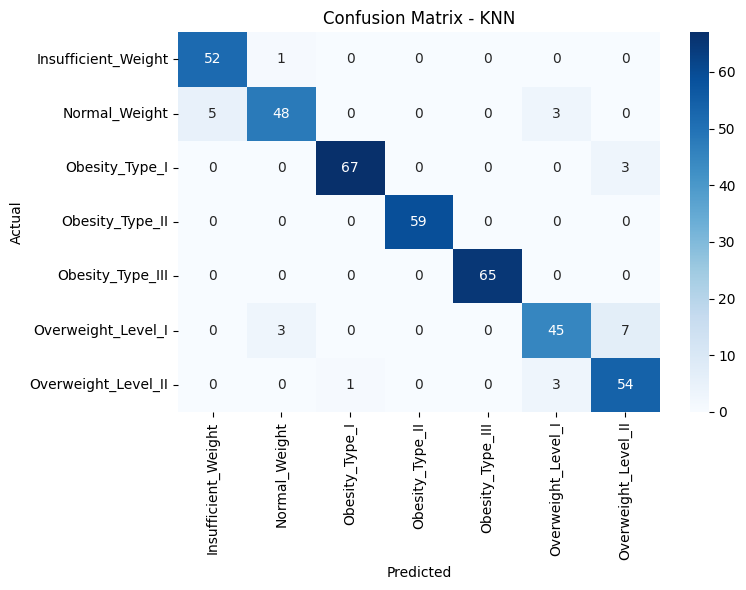

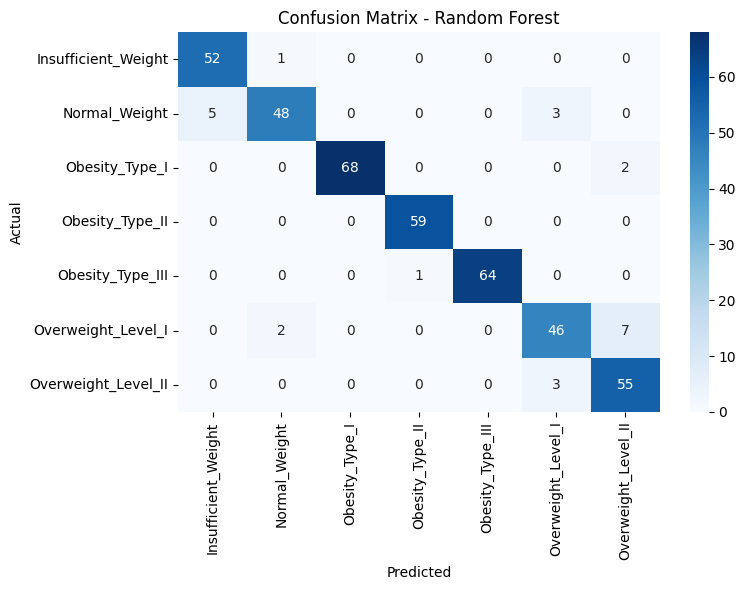

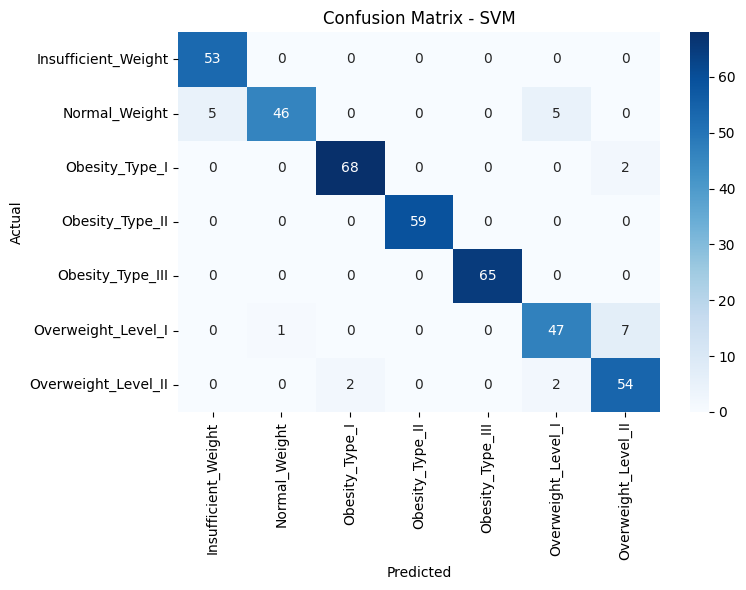

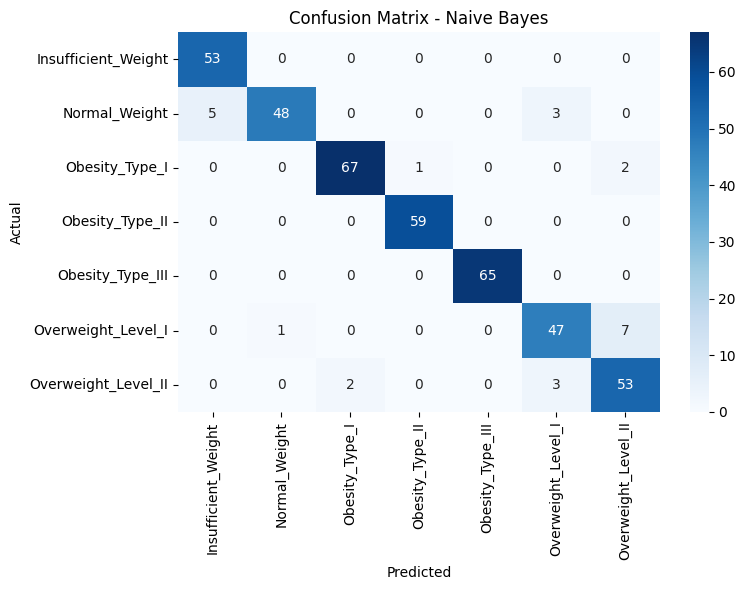

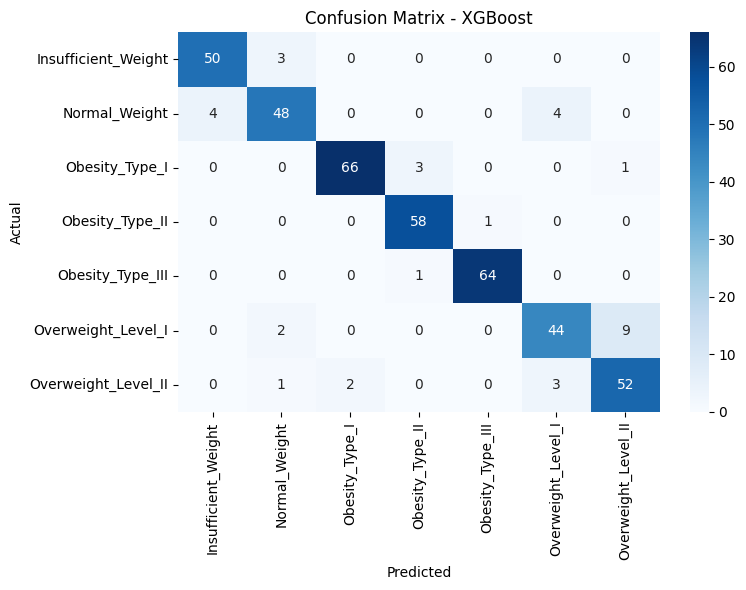

 Model Performance WITH  LDA:



,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
4,Naive Bayes,0.942,0.941,0.940,0.940
3,SVM,0.942,0.942,0.940,0.939
2,Random Forest,0.942,0.940,0.940,0.939
1,KNN,0.938,0.935,0.935,0.934
0,Logistic Regression,0.933,0.932,0.931,0.931
5,XGBoost,0.918,0.915,0.915,0.915


In [25]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

#1. Prepare Data

# Separate features and target
X_raw = df_cleaned.drop('NObeyesdad', axis=1)
y = df_cleaned['NObeyesdad']

# Identify categorical columns
cat_cols = df_cleaned.select_dtypes(include='object').columns.drop('NObeyesdad')  # Exclude target

# One-hot encode categorical features
X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Apply LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y_encoded)

# 3. Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

#  4. Define Models 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

#  5. Train & Evaluate 
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1 Score (Macro)": f1
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#  6. Performance Summary 
results_df = pd.DataFrame(results).sort_values(by="F1 Score (Macro)", ascending=False)
results_df_lda = results_df.copy()
results_df_lda["Condition"] = "With LDA"
print(" Model Performance WITH  LDA:\n")
display(results_df.round(3))


### INSIGHTS FROM MODELS WITH LDA
Naive Bayes performs best across all metrics after applying LDA. Surprisingly, it outperforms even ensemble models like Random Forest and XGBoost.
KNN and SVM are close behind, performing robustly, especially in multiclass classification settings.
XGBoost ranks lowest, which is unusual—possibly due to LDA's linear projection, which may not benefit XGBoost’s tree-based architecture.

### CONFUSION MATRIX ANALYSIS MODEL-WISE 
#### Naive Bayes
Best F1 Score (0.940).

Predicts:
Obesity_Type_I, II, III almost perfectly.
Overweight_Level_I -> Level_II: 7 misclassifications.
Normal_Weight: 8 misclassified.

#### KNN
Strong diagonal dominance (best for Obesity_Type_I = 67 correct).
Slightly confused Overweight_Level_I (7 -> Level_II).
Cleanest results for Obesity and Underweight classes.

#### SVM
Performs very close to KNN.
Similar confusion pattern: Overweight_Level_I and II misclassified.
Clean on Obesity_Type_III, II.

#### Logistic Regression
Solid performance on core obesity classes.
7 misclassified Overweight_Level_I -> II.
General pattern same as SVM.

#### Random Forest
Slight drop in macro metrics compared to others.
More confusion in Insufficient_Weight (1 misclassified).
Misclassifies 9 cases from Overweight_Level_I.

#### XGBoost
Lowest performer here, likely due to the linear compression via LDA.
Confuses:
Overweight_Level_I: 2 predicted as Normal_Weight.
Insufficient_Weight -> Normal_Weight (3 error).
Yet, does well with core obesity types.

### INSIGHTS FROM CONFUSION MATRICES
#### Common Strong Predictions (All Models)
Across almost all models:
Obesity_Type_III and Obesity_Type_II are perfectly or near-perfectly classified.
Obesity_Type_I and Insufficient_Weight also consistently show high accuracy.

This suggests that:
These classes are well-separated in the LDA-projected space.
Features after LDA linearly discriminate these classes effectively.

#### Common Weak Areas
Overweight_Level_I vs Overweight_Level_II
These two classes often get confused with each other.

In KNN, Logistic Regression, and Random Forest:
Overweight_Level_I is sometimes misclassified as Overweight_Level_II and vice versa.
These classes may not be linearly separable after LDA.

Normal_Weight vs Other Classes
Minor misclassifications like Normal_Weight -> Overweight_Level_I or vice versa.
Models like XGBoost and Random Forest struggle more here.

### Why LDA Works Well Here
LDA projects data in a way that maximizes class separability.
Since this is a classification task with 7 classes, LDA (with n_components=2) tries to preserve inter-class variance.
Simpler models like Naive Bayes, KNN benefit more from this linear separation than complex tree-based models.

### Multiclass Classification Using Full Feature Set Without Dimensionality Reduction (Without LDA)

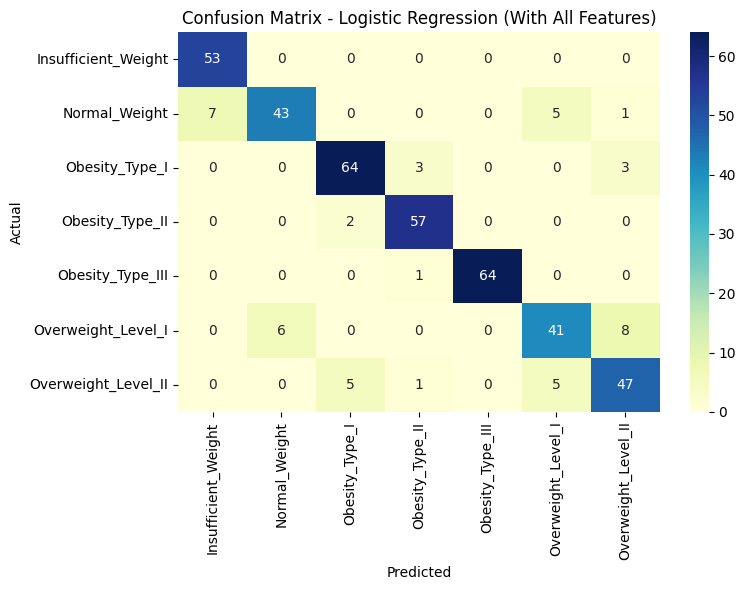

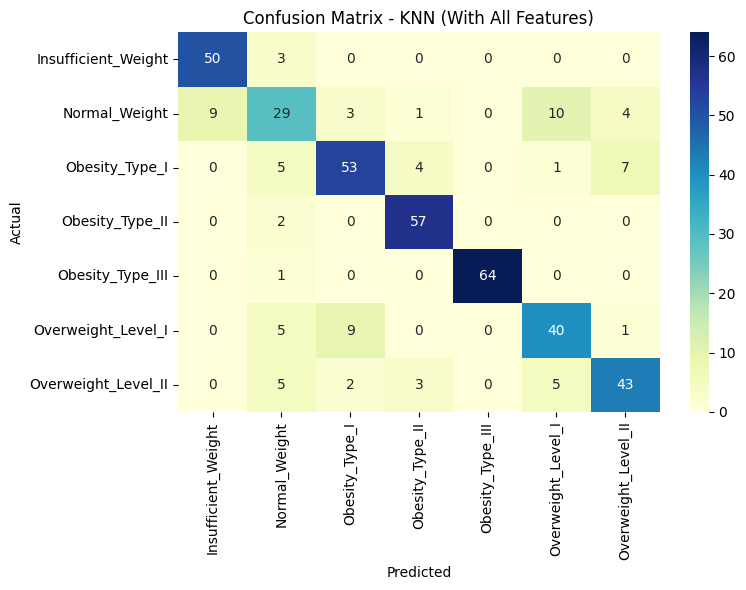

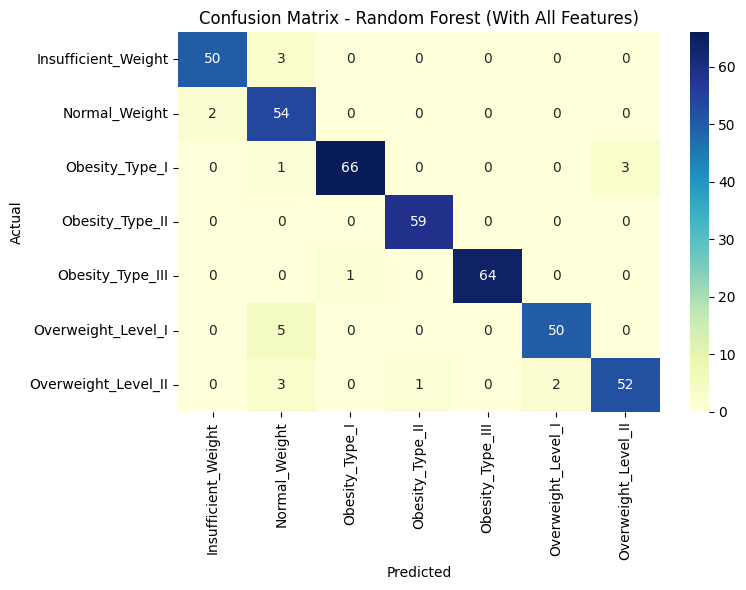

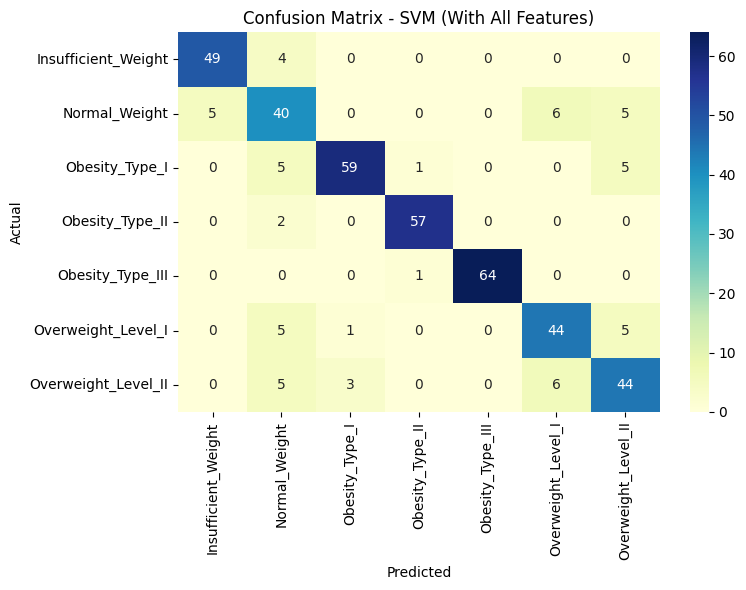

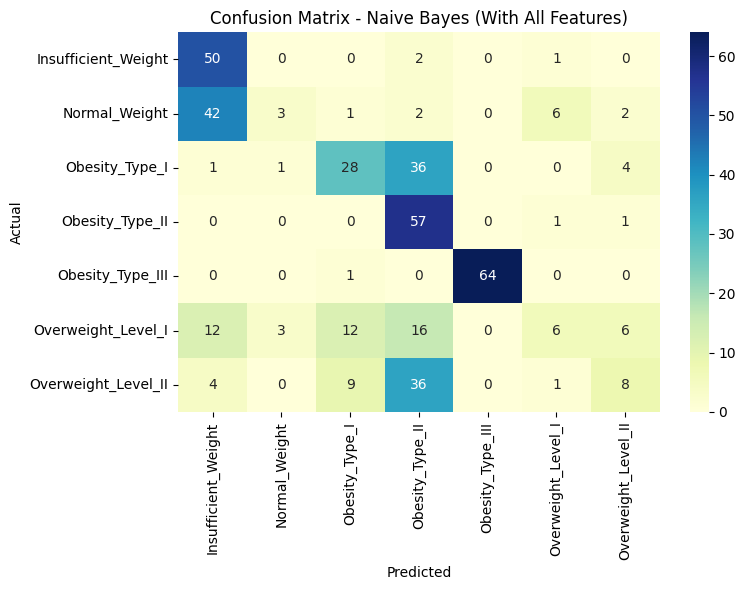

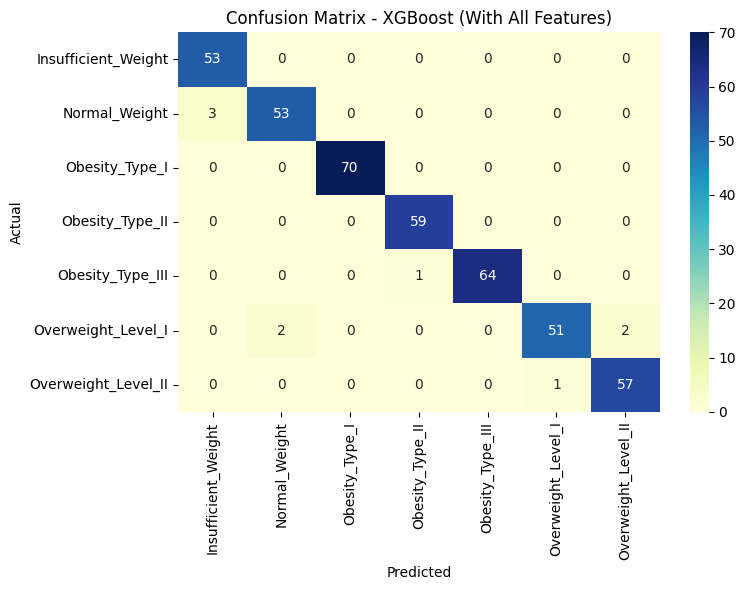

 Model Performance without LDA):



,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),Support
5,XGBoost,0.978,0.977,0.977,0.977,416.0
2,Random Forest,0.950,0.951,0.949,0.949,416.0
0,Logistic Regression,0.887,0.883,0.884,0.882,416.0
3,SVM,0.858,0.857,0.856,0.856,416.0
1,KNN,0.808,0.799,0.805,0.801,416.0
4,Naive Bayes,0.519,0.514,0.514,0.441,416.0


In [26]:
#  Step 1: Encode Categorical Features (completed in previous code)
#  Step 2: Encode Target Labels (completed in previous code)
#  Step 3: Scale Features (completed in previous code)

#  Step 4: Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

#  Step 5: Define Models 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

#  Step 6: Fit & Evaluate 
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1 Score (Macro)": f1,
        "Support": sum(report[str(label)]["support"] for label in model.classes_ if str(label) in report)
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=le.inverse_transform(model.classes_),
                yticklabels=le.inverse_transform(model.classes_))
    plt.title(f"Confusion Matrix - {name} (With All Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#  Step 7: Summary Table 
results_df = pd.DataFrame(results).sort_values(by="F1 Score (Macro)", ascending=False)
results_df_no_lda = results_df.copy()
results_df_no_lda["Condition"] = "Without LDA"
print(" Model Performance without LDA):\n")
display(results_df.round(3))


## Observations & Insights from Model Performance (Without LDA, With All Features)
### CONFUSION MATRIX ANALYSIS MODEL-WISE
#### XGBoost Classifier
Best overall performance (F1 = 0.977).
Perfect or near-perfect classification across all obesity levels.
Minimal misclassification: e.g., Overweight_Level_II had only 1 misclassified instances.
Handles non-linear interactions and high-dimensional data well due to gradient boosting.
Most suitable model for this task.

##### Observation:
Strong separation across all 7 classes.
Rare confusion between neighboring categories like Overweight I and II, unlike other models.


#### Random Forest
Very close to XGBoost (F1 = 0.949).
Strong performance across classes with slight confusion:
Overweight_Level_I misclassified as Normal Weight (5 times).
Overweight_Level_II misclassified into neighboring classes like Obesity Type I or II (2-3 times).
Very good generalization and interpretability.

##### Observation:
Small amount of class overlap in close-range classes (e.g., Overweight-Level_I vs Normal_Weight).
Still robust and accurate.

#### Logistic Regression
Performs well with F1 = 0.882.
Misclassifies:
Overweight_Level_I (14 misclassified cases)
Overweight_Level_II (11 misclassified cases)
Underperforms slightly in borderline categories, due to its linear nature.

##### Observation:
Linear model may not capture the complex relationship between features and obesity level.
Still good for interpretable modeling.

#### 4. SVM
Moderate performance (F1 = 0.856).
Misclassification examples:
Normal Weight -> Overweight_Level_I or II
Obesity_Type_I <-> Type_II
Struggles with some overlapping boundaries.

##### Observation:
Marginally behind Logistic Regression.
Effective in separating some classes but not all.

#### 5. KNN
Weaker performance (F1 = 0.801).
Significant confusion observed:
Normal_Weight misclassified as Overweight_Level_I or II.
Obesity_Type_I confused with others.
Sensitive to class imbalance and feature scaling.

##### Observation:
Performance degraded likely due to high-dimensionality affecting distance metrics.
Should be avoided or used with dimensionality reduction.

#### 6. Naive Bayes
Worst performance (F1 = 0.441).
Misclassifications in almost every class:
Normal Weight often predicted as Insufficient or Overweight.
Poor at distinguishing among Obesity Types.
Strong independence assumption is unrealistic for this dataset.

##### Observation:
Not suitable for multi-class obesity classification.
Class distributions are not well-separated in Naive Bayes feature space.

### Overall Insights
Best Performing:
XGBoost is clearly the most accurate and reliable, followed closely by Random Forest.
These models also show excellent performance in confusion matrices — nearly diagonal matrices with low misclassification rates.

Worst Performing:
Naive Bayes is the least effective due to oversimplified assumptions, making it unsuitable for this problem.
KNN and SVM perform decently but may require tuning or dimensionality reduction for improved results.

Common Error Patterns:
Many models confuse adjacent weight levels, especially:
Normal vs Overweight_Level_I
Overweight_Level_I vs II
Obesity_Type_I vs II


### Model Performance Comparison (With vs Without LDA) Across Key Metrics

In [27]:
comparison_df = pd.concat([results_df_lda, results_df_no_lda], ignore_index=True)

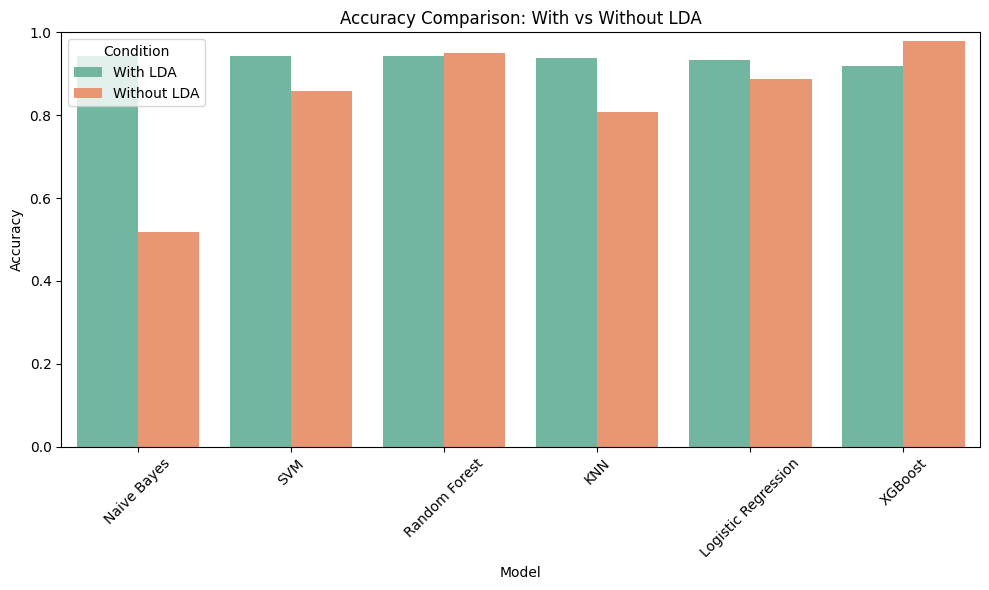

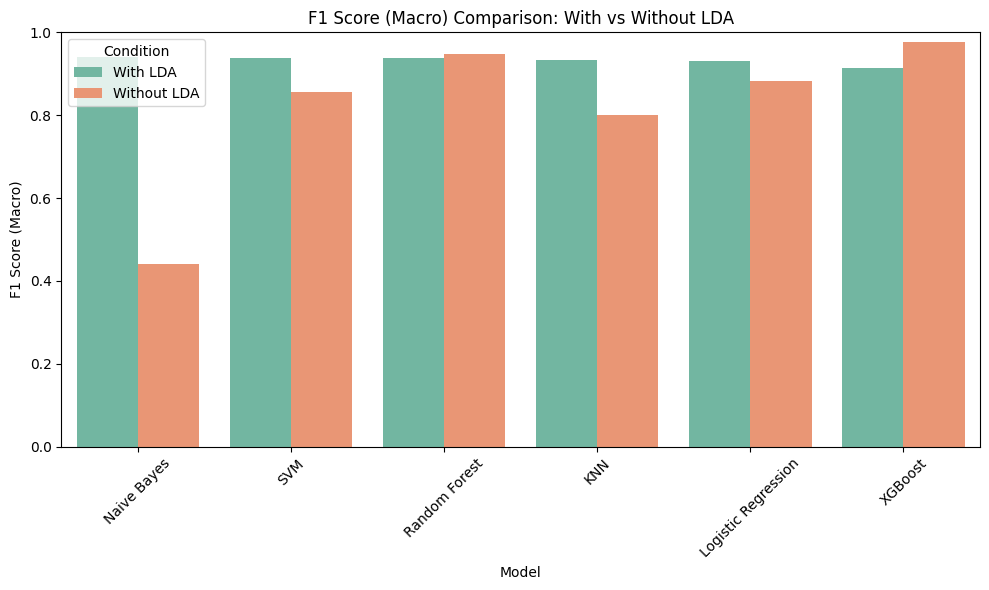

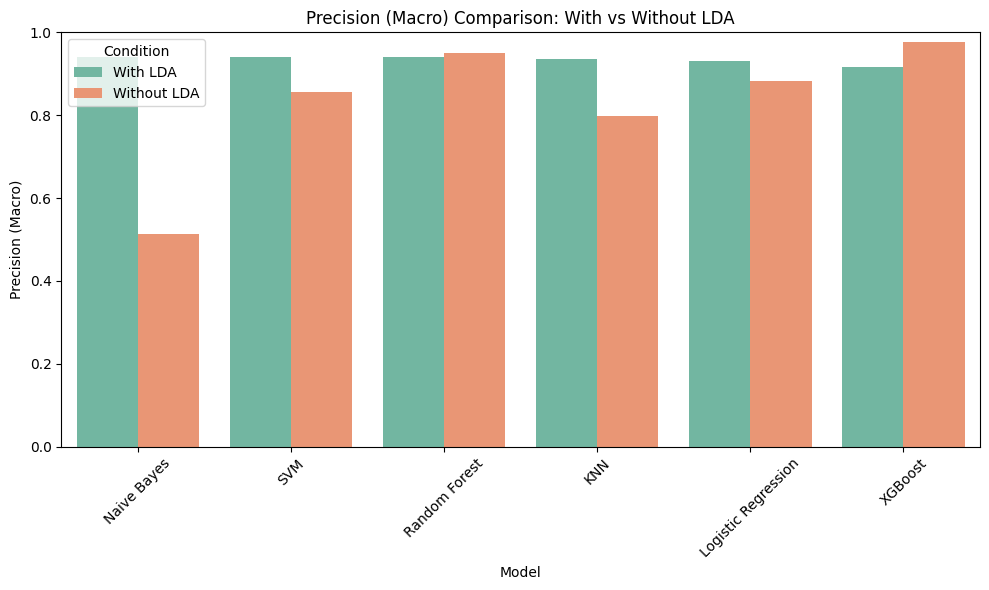

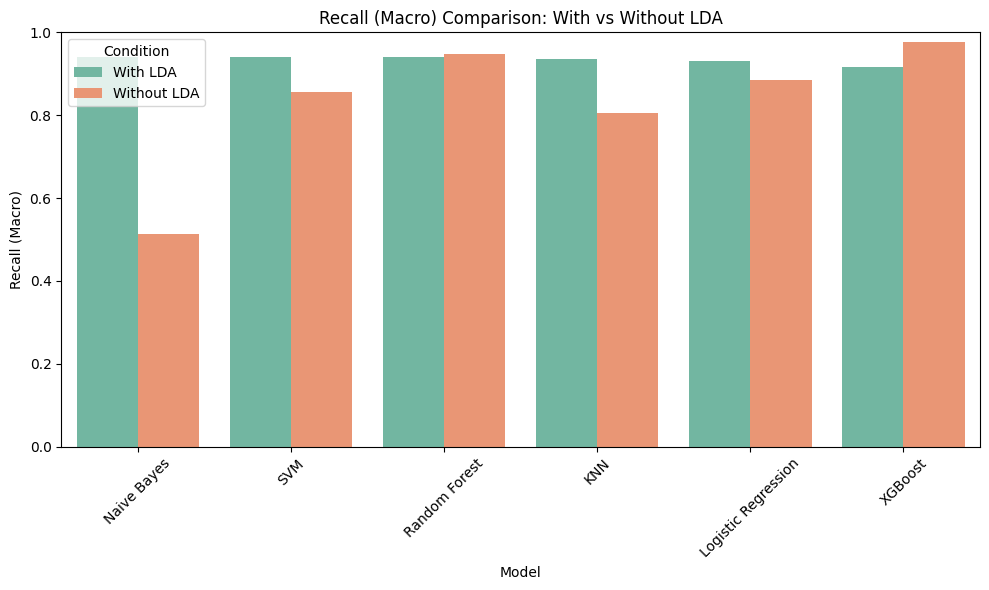

In [28]:
# Step 3: Metrics to Compare
metrics_to_plot = ["Accuracy", "F1 Score (Macro)", "Precision (Macro)", "Recall (Macro)"]

# Step 4: Plot loop
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_df, x="Model", y=metric, hue="Condition", palette="Set2")
    plt.title(f"{metric} Comparison: With vs Without LDA")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

### Observation:
LDA is highly beneficial for models that are sensitive to feature distribution, such as Naive Bayes, KNN, and SVM.

Ensemble models (Random Forest, XGBoost) already perform feature selection and modeling well; hence, LDA adds minimal or even slightly negative value.

### Verdict: 
Without LDA is perferred over with LDA as F1 Score is highest in without LDA.
Hence without LDA is used for Hyperparameter tuning.

### Hyperparameter Tuning and Model Optimization using GridSearchCV

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer
)

# 1. Prepare features and target (completed in previous code)
# One-hot encode categorical features (completed in previous code)
# Encode target labels (completed in previous code)

# 2. Train-Test Split
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 3. Define parameter grids
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__penalty": ['l2'],
        "model__solver": ['lbfgs']
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ['uniform', 'distance']
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ['rbf', 'linear']
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6, 10],
        "model__learning_rate": [0.01, 0.1, 0.3]
    }
}

# 4. Define models
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# 5. Grid SearchCV Evaluation
scorer = make_scorer(f1_score, average='macro')
tuned_results = []

for name, model in base_models.items():
    print(f" Tuning {name}...")

    # Create pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    grid = GridSearchCV(pipeline, param_grids[name], cv=3, scoring=scorer, n_jobs=-1)
    grid.fit(X_train_orig, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_orig)

    # Collect evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    tuned_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": acc,
        "Precision (Macro)": prec,
        "Recall (Macro)": rec,
        "F1 Score (Macro)": f1
    })

    print(f" Best Params: {grid.best_params_}")
    print(f" F1 Score: {f1:.3f}, Accuracy: {acc:.3f}")
    print("-" * 50)

# 6. Summary Results
tuned_df = pd.DataFrame(tuned_results).sort_values(by="F1 Score (Macro)", ascending=False)
print("\n Tuned Model Comparison:\n")
display(tuned_df.round(3))


 Tuning Logistic Regression...
 Best Params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
 F1 Score: 0.933, Accuracy: 0.935
--------------------------------------------------
 Tuning KNN...
 Best Params: {'model__n_neighbors': 3, 'model__weights': 'distance'}
 F1 Score: 0.807, Accuracy: 0.817
--------------------------------------------------
 Tuning Random Forest...
 Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
 F1 Score: 0.951, Accuracy: 0.952
--------------------------------------------------
 Tuning SVM...
 Best Params: {'model__C': 10, 'model__kernel': 'linear'}
 F1 Score: 0.958, Accuracy: 0.959
--------------------------------------------------
 Tuning XGBoost...
 Best Params: {'model__learning_rate': 0.3, 'model__max_depth': 6, 'model__n_estimators': 200}
 F1 Score: 0.977, Accuracy: 0.978
--------------------------------------------------

 Tuned Model Comparison:



,Model,Best Params,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
4,XGBoost,"{'model__learning_rate': 0.3, 'model__max_dept...",0.978,0.977,0.977,0.977
3,SVM,"{'model__C': 10, 'model__kernel': 'linear'}",0.959,0.958,0.959,0.958
2,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.952,0.956,0.951,0.951
0,Logistic Regression,"{'model__C': 10, 'model__penalty': 'l2', 'mode...",0.935,0.934,0.935,0.933
1,KNN,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.817,0.806,0.812,0.807


### MODEL-WISE OBSERVATION
#### XGBoost
Best Model overall.
F1 Score & Accuracy: 0.977, 0.978 -> extremely consistent.
Best Params: max_depth=6, learning_rate=0.3, n_estimators=200.
Strengths:
Learns complex non-linear relationships.
Robust to overfitting due to built-in regularization.
Excellent for handling class imbalance and feature interactions.
Recommended For: Deployment and critical classification tasks.

#### SVM (Linear Kernel)
F1 Score & Accuracy: 0.958, 0.959 -> second-best performer.
Best Params: C=10, kernel='linear' -> indicates the data is linearly separable to a good extent.
Strengths:
Works well in high-dimensional spaces.
Effective in cases with clear margin of separation.
Trade-offs:
Slower with large datasets.
May not capture non-linear boundaries (as already tested rbf, but linear performed better).

#### Random Forest
F1 Score & Accuracy: 0.951, 0.952.
Best Params: max_depth= None, n_estimators=200, min_samples_split=2.
Strengths:
Captures feature interactions and non-linearity.
Less prone to overfitting than decision trees.
Can provide feature importance.
Use Case: Great backup model and for explaining predictions.

#### Logistic Regression
F1 Score & Accuracy: 0.933, 0.935.
Best Params: C=10, penalty='l2'.
Strengths:
Simple, fast, and interpretable.
Performs well when data is linearly separable.
Limitations:
Struggles with non-linearity or complex class boundaries.
Use Case: Great baseline model or for explainability.

#### KNN
F1 Score & Accuracy: 0.807, 0.817.
Best Params: n_neighbors=3, weights='distance'.
Weaknesses:
Sensitive to feature scaling.
Performs poorly in high-dimensional or overlapping class boundaries.
Computationally expensive during prediction.
Use Case: Educational comparison only—not recommended for production.


### Performance Metrics Visualization of Tuned Models (Without LDA)

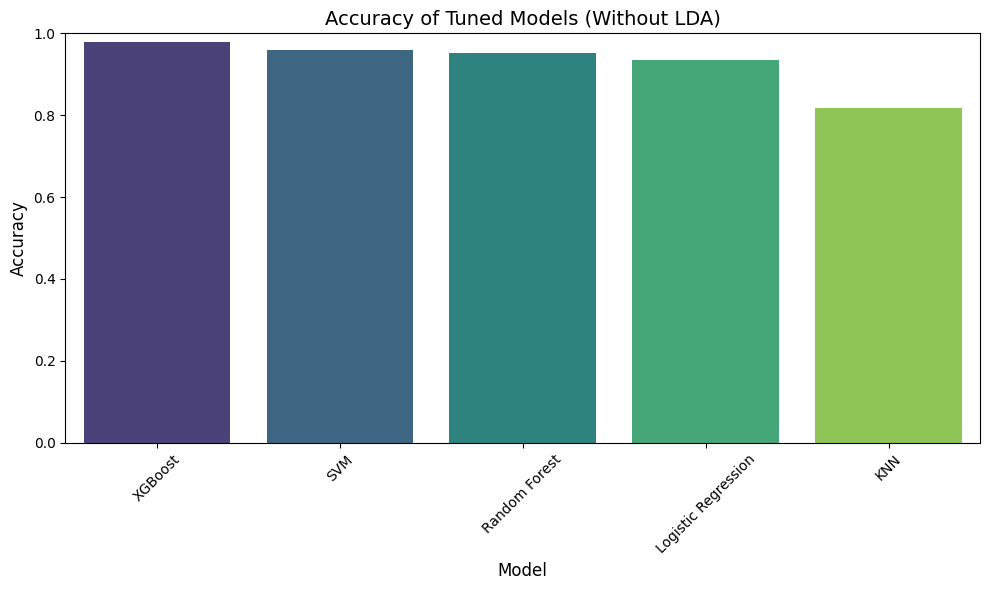

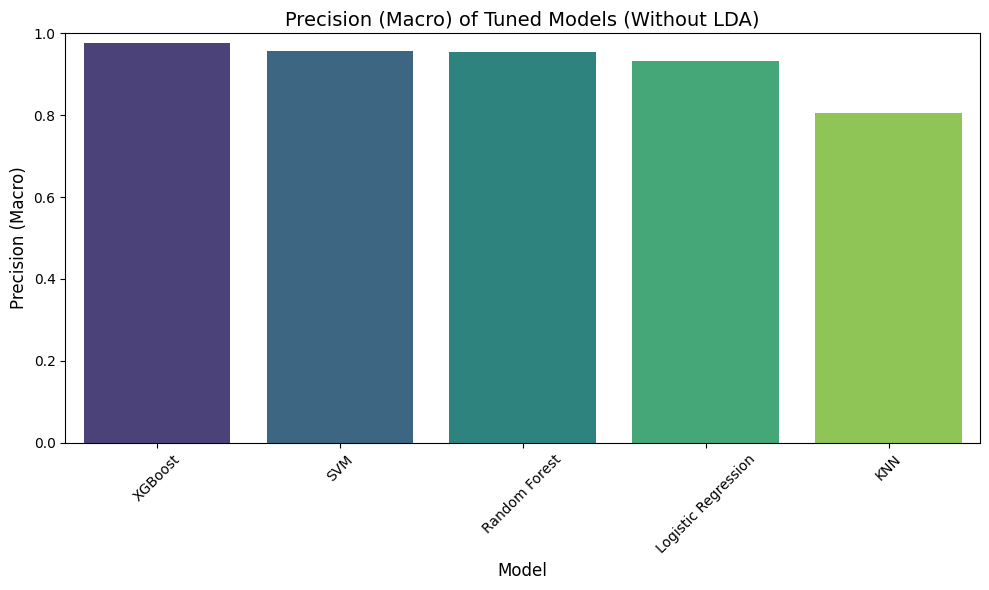

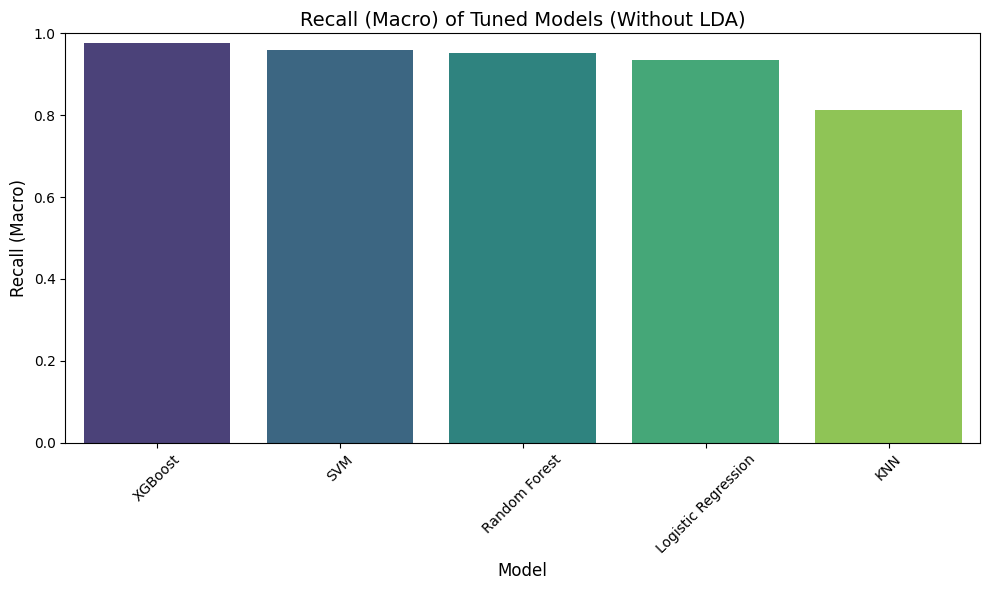

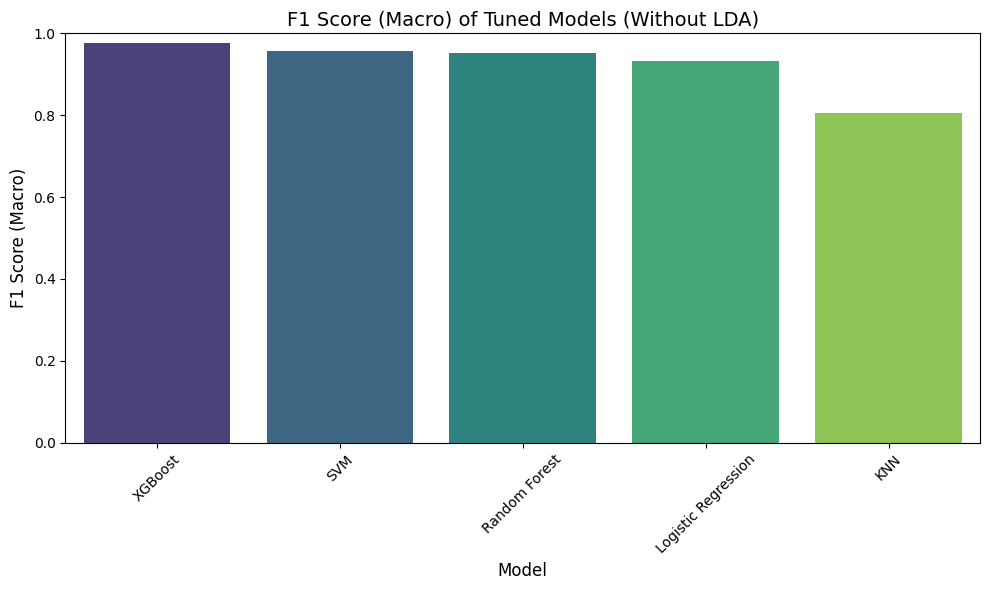

In [30]:

metrics_to_plot = ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    
    plot_data = tuned_df.sort_values(by=metric, ascending=False)

    # Assign hue to fix future warning and suppress legend manually
    sns.barplot(data=plot_data, x="Model", y=metric, hue="Model", palette="viridis", dodge=False)
    
    plt.title(f"{metric} of Tuned Models (Without LDA)", fontsize=14)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend([], [], frameon=False)
    plt.tight_layout()
    plt.show()


### Observation:
It is visible that the best performing model is XGBoost from all the plots of F1 score, Recall, Precision and Accuracy.

### Final Insights
#### Model Stability:
High consistency between training and test F1 scores suggests low overfitting, especially for XGBoost, SVM, and Random Forest.

#### Feature Scaling:
Models like SVM, KNN, and Logistic Regression benefit from StandardScaler— pipeline handles this effectively.

#### Complexity vs Performance:
Simpler models (LogReg, KNN) are competitive but not optimal.
Tree-based ensembles and margin-based models (SVM) shine on structured datasets like this.

### Recommendable Actions
For Deployment:
XGBoost (Best overall)
Random Forest (Backup model, also explainable)

For Model Explanation:
Random Forest or Logistic Regression to extract feature importance or coefficient weights.

### Top 15 Important Features across different models

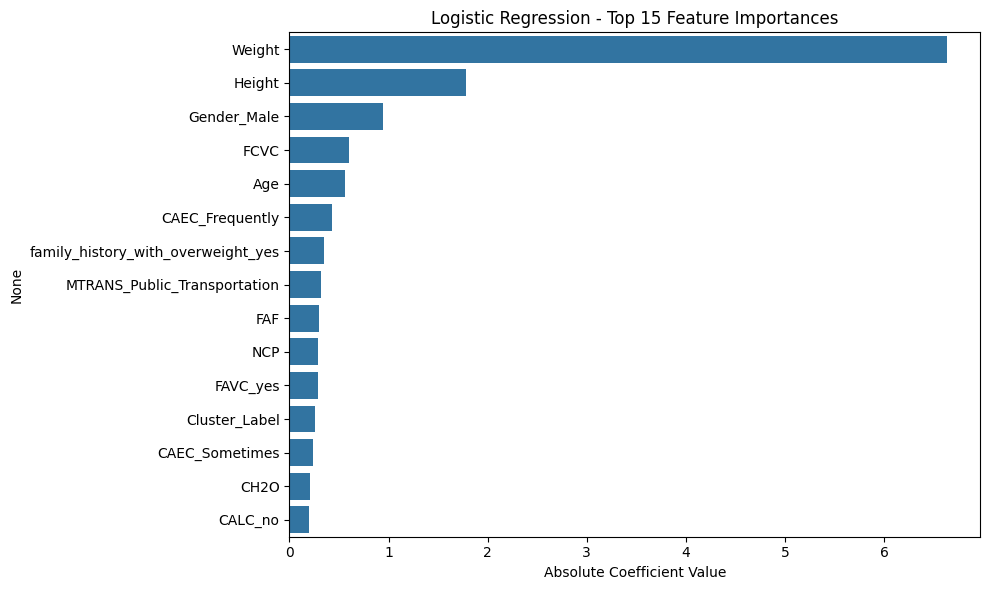

In [31]:

# Train logistic regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_scaled, y_encoded)

# Coefficients
coef = lr_model.coef_
if coef.shape[0] > 1:
    coef = np.mean(np.abs(coef), axis=0)  # Multiclass
else:
    coef = coef[0]

importance = pd.Series(np.abs(coef), index=X_encoded.columns).sort_values(ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values[:15], y=importance.index[:15])
plt.title("Logistic Regression - Top 15 Feature Importances")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()


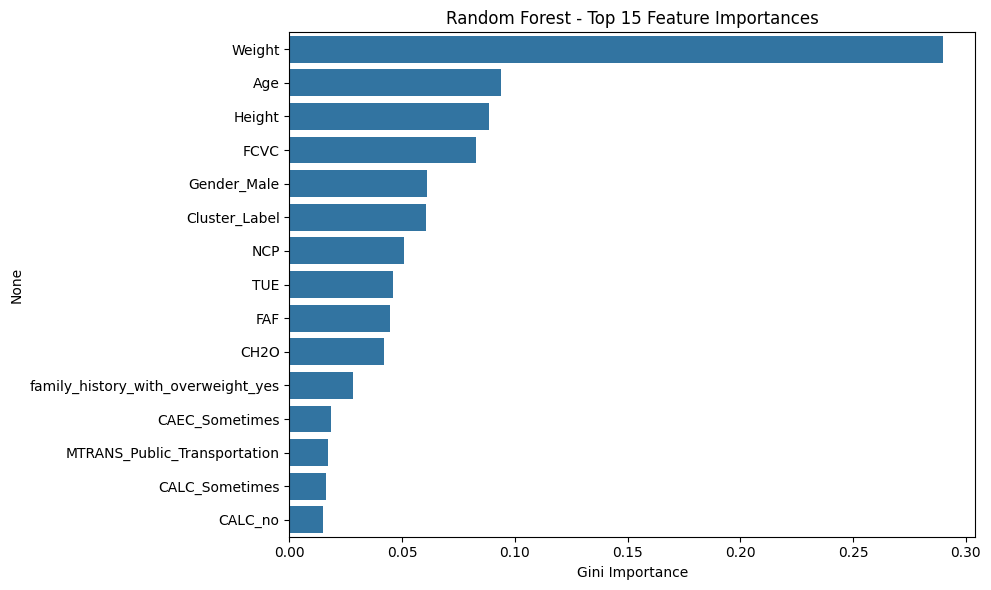

In [32]:

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_encoded, y_encoded)

importance = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values[:15], y=importance.index[:15])
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.show()


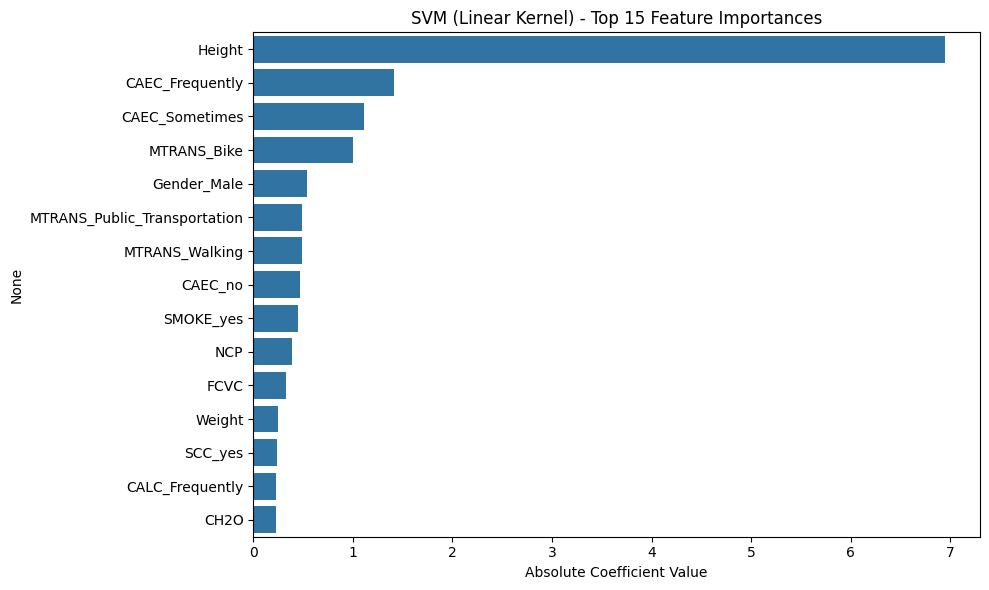

In [33]:

svm_model = SVC(kernel='linear')
svm_model.fit(X_encoded, y_encoded)

coef = svm_model.coef_[0]
importance = pd.Series(np.abs(coef), index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values[:15], y=importance.index[:15])
plt.title("SVM (Linear Kernel) - Top 15 Feature Importances")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()


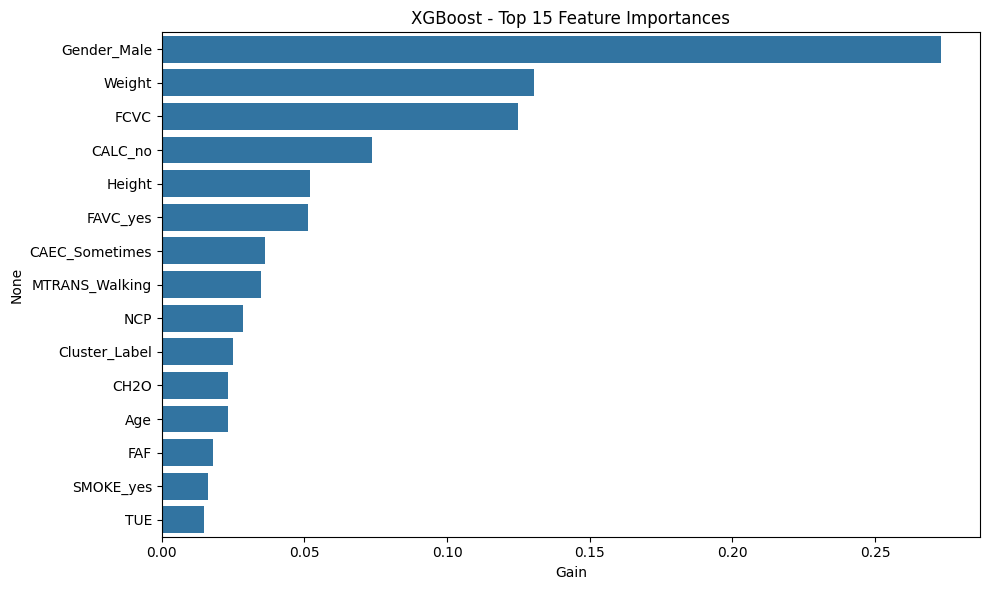

In [34]:

xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_encoded, y_encoded)

importance = pd.Series(xgb_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values[:15], y=importance.index[:15])
plt.title("XGBoost - Top 15 Feature Importances")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()


### Key Insights 
#### Most Consistently Important Features:
Weight, Height, Gender_Male, FCVC, Age
These appear across all four models, suggesting they are strong baseline predictors.

#### Model Sensitivities:
XGBoost: Captures nonlinear and categorical patterns well (e.g., CALC_no, FAVC_yes).

SVM: Highly influenced by height and caloric consumption; less trustable for weight influence due to linearity and possible feature scaling.

Random Forest: Balanced, reliable for both continuous and categorical factors; great for interpretability with non-linear splits.

Logistic Regression: Prioritizes direct relationships, suitable for explanation but not complex interactions.

### Important Finding
Although the linear SVM performs competitively, its feature importance does not align with established medical understanding of obesity—specifically undervaluing weight. This limits its interpretability and application in health contexts.

### Final Verdict:
After a comprehensive evaluation across multiple dimensions—predictive performance, feature importance alignment, and interpretability—it is evident that XGBoost emerges as the most effective model for the obesity classification task. Its ability to capture complex, nonlinear relationships and handle both categorical and continuous features makes it particularly well-suited for this domain.

Random Forest stands out as the next best alternative, offering a strong balance between accuracy and interpretability, with feature importance that aligns well with established medical understanding. In contrast, SVM, despite competitive performance, demonstrates limitations in capturing key health-related predictors like weight, reducing its reliability for clinical or health-related applications.

### CONCLUSION (SUMMARY OF WORK FLOW)
#### 1.Importing essential libraries and Data Loading
Objective: Import raw data into the analysis environment and to get a preview of data to understand it.

#### 2. Checking for missing values (Part of Data Cleaning)
Objective: For missing value treatment (not required in this dataset) and make the data more consistent
Techniques: None used as there were no missing values.

#### 3. Univariate EDA before outlier treatment 
Objective: Detect outliers based on relationships between variables.
Visualizations: histograms, boxplots.

#### 4. Data Cleaning
Objective: Fix or remove incorrect, incomplete, or inconsistent data.

Steps:

-Removing duplicates.

-Outlier Treatment.

Techniques used for Outlier Treatment:

a) DBSCAN - DBSCAN is non-parametric and doesn’t make such assumptions like the traditional methods (e.g., Z-score or IQR) assume a normal (Gaussian) distribution.

b) Isolation forest- Purely used for handling high-dimensional data and captures multivariate interactions like DBSCAN.

Choice: DBSCAN as it detects both clusters and outliers and better for visualization.
DBSCAN is more Interpretable through eps and min_samples and finds local outliers better than Isolation forest as Isolation forest mostly covers global outliers and may miss local density differences.


#### 5. Post Cleaning EDA
Objective: Re-examine relationships once the extreme values are removed, capped, or treated.
See how patterns, correlations, and trends change without the influence of outliers.
Build cleaner insights that are more generalizable for modeling.

Descriptive statistics.

Visualizations:

Bivariate and multivariate visualization

##### 1. Purpose of PCA AND t-SNE Plots

Plot Type	Purpose:
PCA (Principal Component Analysis)	Linear dimensionality reduction; projects data onto directions of maximum variance.
t-SNE (t-Distributed Stochastic Neighbor Embedding)	Nonlinear technique; preserves local structure and clusters in lower dimensions.

##### 2.Purpose of using LDA projection

 1. Visualizing Class Separation
LDA reduced the high-dimensional data (features like Age, Weight, Physical Activity, etc.) to 2D, allowing a clear visualization of how well obesity categories (NObeyesdad) are separated.

 2. Understanding Class Distinction
It helped assess how distinctly different obesity levels (e.g., Normal_Weight, Obesity_Type_II) are grouped based on lifestyle and physiological features.

 3. Evaluating Feature Discriminative Power
LDA tested whether the selected features effectively distinguish between obesity classes, indicating good potential for classification.

 4. Improving Classification Readiness
Besides visualization, LDA also prepares the dataset for classification by reducing dimensions while preserving class-related information, potentially improving model performance.ion, but also to reduce noise and improve the performance of classification models by using a smaller set of linearly discriminant features.

Additional pattern identification through Agglomerative Clustering and linked them to obesity levels using heatmaps.

#### 6. Feature Engineering
Objective: To create, transform, or select features that improve the performance, accuracy, and interpretability of data models by making relevant patterns in the data more accessible to algorithms.

LDA for Dimensionality Reduction
Transform existing features:
Scaling: StandardScaler
Encoding categorical variables:
One-hot encoding
Label encoding
Target encoding 



#### 7. Splitting Data and Model Training (With and Without Dimensionality Reduction)
Objective: Divide the dataset into training, test sets.
Typical split: 80% training, 20% testing. (Random State used is 42)

Model Types Used:

Classification (Logistic Regression, KNN, SVM, XGBoost, Random Forest, Naive Bayes.)
As the dataset is a multiclass-classification problem hence the above model types were used.

#### 8. Model Evaluation
Objective: Assess the performance of the trained model.

Metrics Used:
Classification: Accuracy, Precision, Recall, F1-score.

#### 9. Hyperparameter Tuning
Objective: Optimize model parameters for better performance.

Method Used:
Grid Search


#### 10. Model Interpretation
Objective: Understand how the model makes predictions.

##### Technique used for feature Importance:

##### Model ->	Feature Importance Method

Logistic Regression	-> Absolute Coefficients

Random Forest ->	Gini Importance (MDI)

Linear SVM	-> Absolute Coefficients

XGBoost	-> Gain (Loss Reduction)

#### Final Verdict was given based on a multi-dimensional analysis of the models and with proper understanding of domain knowledge. Hence the best model for Obesity dataset is XGBoost.